# Table of Content

---

- <a href='#c1'> 1. Import modules, building classes and read CSV </a>

- <a href='#c2'> 2. Exploratory data analysis </a>

- <a href='#c3'> 3. Data Analysis </a>

- <a href='#c4'> 4. Model building</a>

- <a href='#c5'> 5. Validation</a>

- <a href='#c6'> 6. Results and submission</a>

---

<a id='c1'></a>
# <div style="text-align:center; border-radius:15px 15px; padding:15px; color:#333333; margin:0; ; padding:15px; font-size:100%; font:'Verdana'; background-color:#F5F5F5;border: 1px; overflow:hidden"><b>1. Import modules, building classes and read CSV</b></div>

In [15]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

!pip install -q sweetviz
import sweetviz as sv 

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.metrics import accuracy_score

import plotly.express as px
import plotly.graph_objects as go

from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

In [16]:
train = pd.read_csv('/kaggle/input/playground-series-s4e11/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s4e11/test.csv')
original = pd.read_csv('/kaggle/input/depression-surveydataset-for-analysis/final_depression_dataset_1.csv')

In [19]:
for col in train.columns:
    print(f"Unique values in {col}:")
    print(train[col].unique())
    print("\n")


Unique values in id:
[     0      1      2 ... 140697 140698 140699]


Unique values in Name:
['Aaradhya' 'Vivan' 'Yuvraj' 'Rhea' 'Vani' 'Ritvik' 'Rajveer' 'Aishwarya'
 'Simran' 'Utkarsh' 'Aahana' 'Tejas' 'Aadhya' 'Kiran' 'Aditi' 'Suhani'
 'Jiya' 'Bhavesh' 'Armaan' 'Ishaani' 'Prachi' 'Pratyush' 'Abhinav'
 'Siddhesh' 'Aditya' 'Aarav' 'Asha' 'Kashish' 'Prisha' 'Chhavi' 'Tanmay'
 'Vihaan' 'Shiv' 'Anvi' 'Darsh' 'Samar' 'Raunak' 'Mahi' 'Shaurya' 'Vidya'
 'Jai' 'Ayush' 'Ansh' 'Anand' 'Yashvi' 'Shrey' 'Ritika' 'Mihir' 'Isha'
 'Arjun' 'Rohan' 'Pratham' 'Nirvaan' 'Ishaan' 'Aarya' 'Riya' 'Aariv'
 'Raghavendra' 'Mahika' 'Abhishek' 'Harshil' 'Janvi' 'Kartikeya' 'Shivam'
 'Advait' 'Reyansh' 'Saanvi' 'Ivaan' 'Pallavi' 'Sneha' 'Ayaan' 'Aakash'
 'Raghav' 'Satyam' 'Aarush' 'Vibha' 'Rupal' 'Sanya' 'Mira' 'Rashi' 'Shlok'
 'Harsha' 'Divya' 'Pranav' 'Hrithik' 'Tushar' 'Garima' 'Zoya' 'Kian'
 'Navya' 'Lakshay' 'Kriti' 'Palak' 'Aryan' 'Parth' 'Ishan' 'Rupak'
 'Atharv' 'Aarti' 'Anirudh' 'Kabir' 'Sanjeev' 'San

In [20]:
unique_values = train.apply(lambda col: col.unique())
print(unique_values)


id                                       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...
Name                                     [Aaradhya, Vivan, Yuvraj, Rhea, Vani, Ritvik, ...
Gender                                                                      [Female, Male]
Age                                      [49.0, 26.0, 33.0, 22.0, 30.0, 59.0, 47.0, 38....
City                                     [Ludhiana, Varanasi, Visakhapatnam, Mumbai, Ka...
Working Professional or Student                            [Working Professional, Student]
Profession                               [Chef, Teacher, nan, Business Analyst, Finanan...
Academic Pressure                                           [nan, 5.0, 2.0, 3.0, 4.0, 1.0]
Work Pressure                                               [5.0, 4.0, nan, 1.0, 2.0, 3.0]
CGPA                                     [nan, 8.97, 5.9, 7.03, 5.59, 8.13, 5.7, 9.54, ...
Study Satisfaction                                          [nan, 2.0, 5.0, 3.0, 4.0, 1.0]

In [3]:
class PlotlyVisualizer:
    def __init__(self, dataframe):
        self.df = dataframe

    def histogram(self, column, title='Histogram', color='blue', hue=None):
        fig = px.histogram(self.df, x=column, color=hue, title=title)
        fig.update_traces(marker_line_color='black', marker_line_width=1.5, opacity=0.7)
        fig.update_xaxes(title_text=column, title_font=dict(size=14, color='black'), tickangle=45)
        fig.update_yaxes(title_text='Count', title_font=dict(size=14, color='black'))
        fig.update_layout(title_font=dict(size=20, color='darkblue'), title_x=0.5, plot_bgcolor='lightgray', paper_bgcolor='white')
        fig.show()

    def scatter(self, x_column, y_column, title='Scatter Plot', color='blue', hue=None):
        fig = px.scatter(self.df, x=x_column, y=y_column, color=hue, title=title)
        fig.update_traces(marker=dict(size=5, line=dict(width=1, color='black')), opacity=0.7)
        fig.update_xaxes(title_text=x_column, title_font=dict(size=14, color='black'))
        fig.update_yaxes(title_text=y_column, title_font=dict(size=14, color='black'))
        fig.update_layout(title_font=dict(size=20, color='darkblue'), title_x=0.5, plot_bgcolor='lightgray', paper_bgcolor='white')
        fig.show()

    def box_plot(self, column, title='Box Plot', color='blue', hue=None):
        fig = px.box(self.df, y=column, color=hue, title=title)
        fig.update_traces(marker_color=color, boxmean='sd')
        fig.update_yaxes(title_text=column, title_font=dict(size=14, color='black'))
        fig.update_layout(title_font=dict(size=20, color='darkblue'), title_x=0.5, plot_bgcolor='lightgray', paper_bgcolor='white')
        fig.show()

    def line_plot(self, x_column, y_column, title='Line Plot', color='blue', hue=None):
        fig = px.line(self.df, x=x_column, y=y_column, color=hue, title=title)
        fig.update_traces(line=dict(width=2), marker=dict(size=5))
        fig.update_layout(title_font=dict(size=20, color='darkblue'), title_x=0.5,
                          xaxis_title=x_column, yaxis_title=y_column,
                          plot_bgcolor='lightgray', paper_bgcolor='white')
        fig.show()

    def bar_chart(self, x_column, y_column, title='Bar Chart', color='blue', hue=None):
        fig = px.bar(self.df, x=x_column, y=y_column, color=hue, title=title)
        fig.update_traces(marker_color=color)
        fig.update_layout(title_font=dict(size=20, color='darkblue'), title_x=0.5, plot_bgcolor='lightgray', paper_bgcolor='white')
        fig.show()

    def pie_chart(self, column, title='Pie Chart', hue=None):
        value_counts = self.df[column].value_counts()
        total = value_counts.sum()
        percentages = (value_counts / total) * 100
        
        filtered_value_counts = value_counts[percentages > 1]
        
        other_sum = value_counts[percentages <= 1].sum()
        
        if other_sum > 0:
            filtered_value_counts['Other'] = other_sum

        fig = px.pie(
            values=filtered_value_counts,
            names=filtered_value_counts.index,
            title=title
        )
        
        fig.update_traces(textinfo='label+percent')  
        fig.update_layout(title_font=dict(size=20, color='darkblue'), title_x=0.5, 
                          plot_bgcolor='lightgray', paper_bgcolor='white')
        fig.show()

    def heatmap(self, x_column, y_column, z_column, title='Heatmap'):
        fig = px.density_heatmap(self.df, x=x_column, y=y_column, z=z_column, title=title)
        fig.update_layout(title_font=dict(size=20, color='darkblue'), title_x=0.5, plot_bgcolor='lightgray', paper_bgcolor='white')
        fig.show()

    def area_chart(self, x_column, y_column, title='Area Chart', color='blue', hue=None):
        fig = px.area(self.df, x=x_column, y=y_column, color=hue, title=title)
        fig.update_traces(fillcolor=color)
        fig.update_layout(title_font=dict(size=20, color='darkblue'), title_x=0.5, plot_bgcolor='lightgray', paper_bgcolor='white')
        fig.show()

    def violin_plot(self, column, title='Violin Plot', color='blue', hue=None):
        fig = px.violin(self.df, y=column, color=hue, title=title)
        fig.update_traces(marker_color=color)
        fig.update_layout(title_font=dict(size=20, color='darkblue'), title_x=0.5, plot_bgcolor='lightgray', paper_bgcolor='white')
        fig.show()

    def sunburst_chart(self, path, title='Sunburst Chart'):
        fig = px.sunburst(self.df, path=path, title=title)
        fig.update_layout(title_font=dict(size=20, color='darkblue'), title_x=0.5, plot_bgcolor='lightgray', paper_bgcolor='white')
        fig.show()

    def missmap(self, title='Missing Data Map'):
        missing_data = self.df.isnull().astype(int)
        missing_data_long = missing_data.reset_index().melt(id_vars="index")
        missing_data_long.columns = ["Row", "Column", "Missing"]
        missing_data_pivot = missing_data_long.pivot_table(index="Row", columns="Column", values="Missing", fill_value=0)
        fig = px.imshow(
            missing_data_pivot,
            color_continuous_scale=["#3498db", "#e74c3c"],
            labels={"color": "Missing"},
            title=title
        )
        fig.update_layout(
            title_font=dict(size=20, color='darkblue'), 
            title_x=0.5,
            xaxis_title="Columns", 
            yaxis_title="Rows",
            plot_bgcolor='lightgray', 
            paper_bgcolor='white'
        )
        fig.show()

pv = PlotlyVisualizer(train)

<a id='c2'></a>
# <div style="text-align:center; border-radius:15px 15px; padding:15px; color:#333333; margin:0; ; padding:15px; font-size:100%; font:'Verdana'; background-color:#F5F5F5;border: 1px; overflow:hidden"><b> 2. Exploratory Data Analysis </b></div>

## Dataset Description



This dataset contains information on individuals' mental health, work/study life, and demographics. It includes 140,700 entries with 20 columns, detailing various aspects like academic pressure, job satisfaction, dietary habits, and mental health history.



#### Columns:

1. **id**: Unique identifier for each entry (int).

2. **Name**: Name of the individual (string).

3. **Gender**: Gender of the individual (string).

4. **Age**: Age of the individual (float).

5. **City**: City of residence (string).

6. **Working Professional or Student**: Indicates if the individual is a working professional or student (string).

7. **Profession**: Profession of the individual, where applicable (string, 74% non-null).

8. **Academic Pressure**: Academic pressure level (float, 20% non-null).

9. **Work Pressure**: Work pressure level (float, 80% non-null).

10. **CGPA**: Current Grade Point Average for students (float, 20% non-null).

11. **Study Satisfaction**: Satisfaction with studies (float, 20% non-null).

12. **Job Satisfaction**: Satisfaction with job (float, 80% non-null).

13. **Sleep Duration**: Duration of sleep (string).

14. **Dietary Habits**: Dietary habits of the individual (string).

15. **Degree**: Degree the individual holds (string).

16. **Have you ever had suicidal thoughts?**: Indicates if the individual has experienced suicidal thoughts (string).

17. **Work/Study Hours**: Number of hours spent working or studying daily (float).

18. **Financial Stress**: Financial stress level (float).

19. **Family History of Mental Illness**: Indicates if there is a family history of mental illness (string).

20. **Depression**: Indicates presence of depression (int).



#### Data Summary:

- **Total Entries**: 140,700

- **Total Columns**: 20

- **Memory Usage**: Approximately 21.5 MB


In [4]:
target = 'Depression'

numerical_columns = [
    "Age", "Academic Pressure", "Work Pressure", "CGPA",
    "Study Satisfaction", "Job Satisfaction", "Work/Study Hours",
    "Financial Stress"
]

one_hot_columns = [
    "Gender", "Working Professional or Student", "City", "Family History of Mental Illness"
]

label_columns = [
    "Degree", "Profession", "Dietary Habits", "Have you ever had suicidal thoughts ?", "Sleep Duration"
]

In [5]:
pv.pie_chart(target)

                                             |          | [  0%]   00:00 -> (? left)


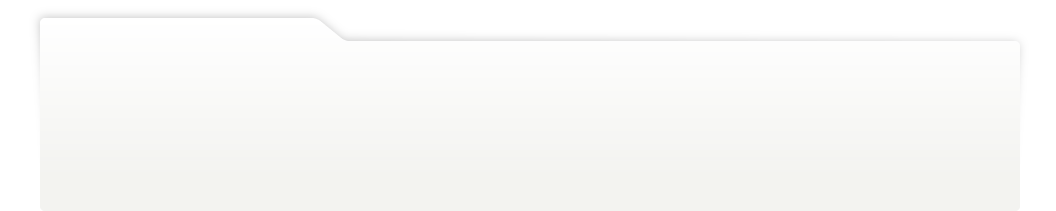
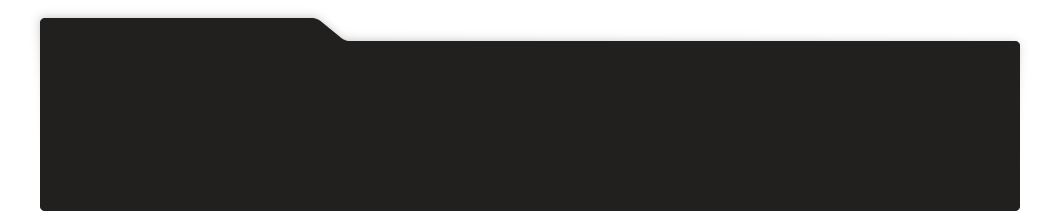
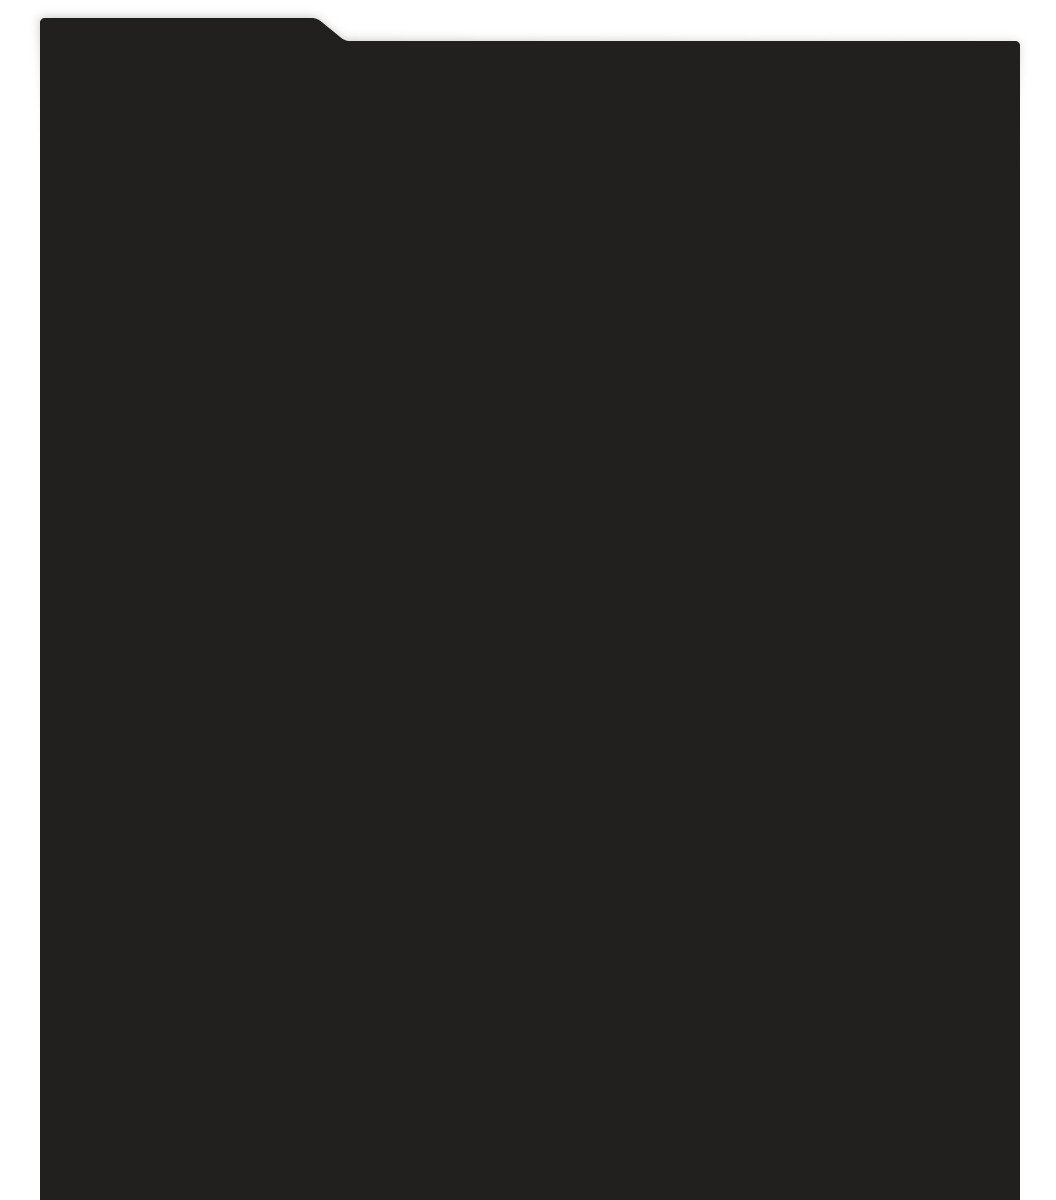
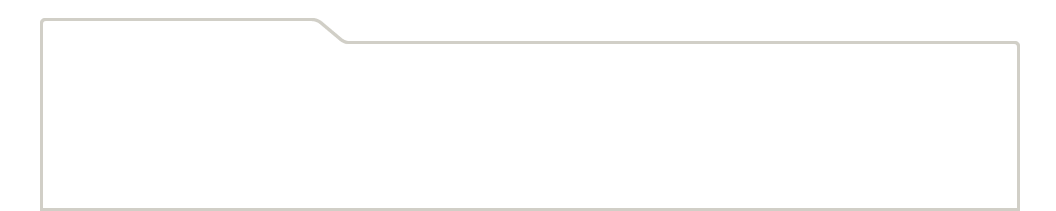
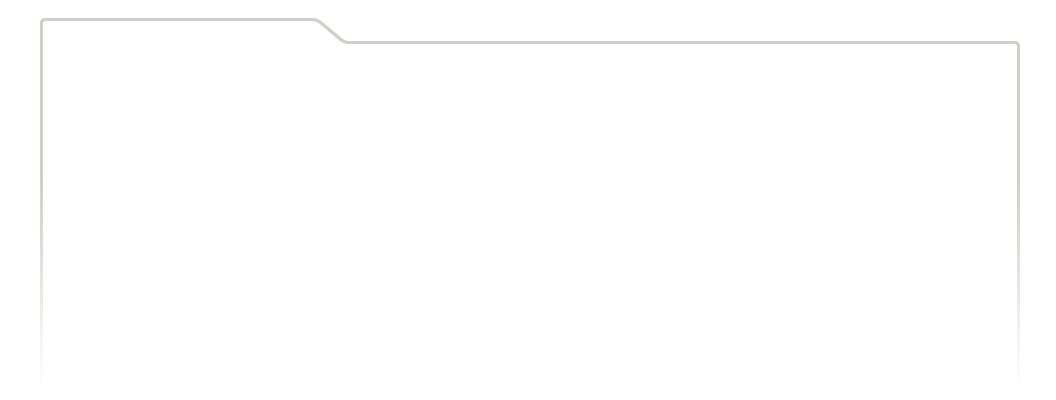
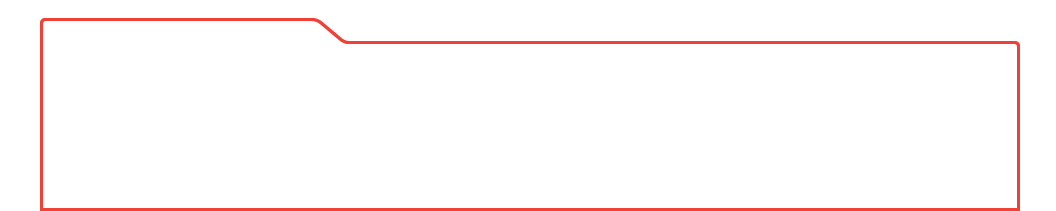
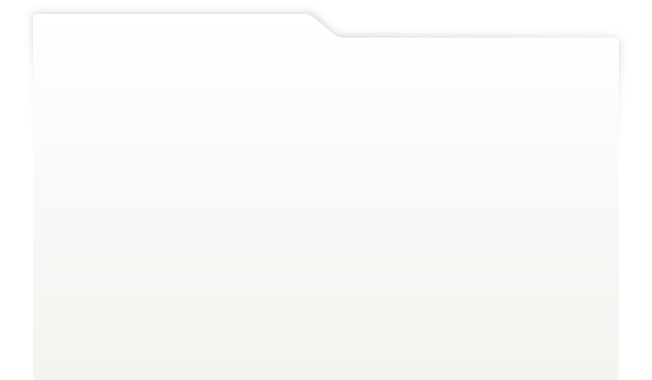
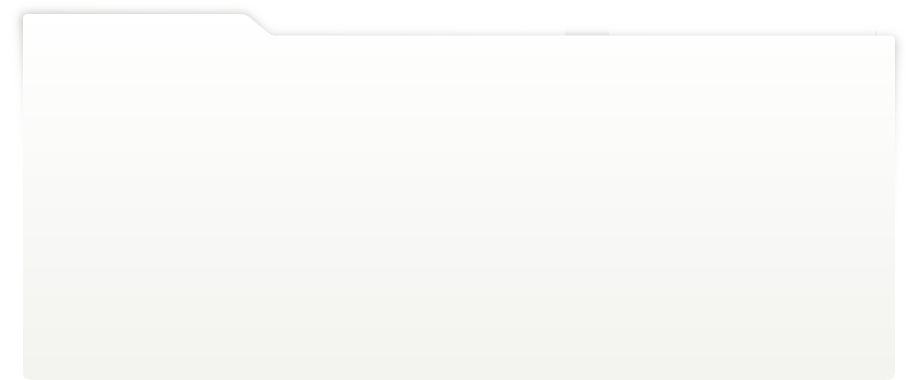
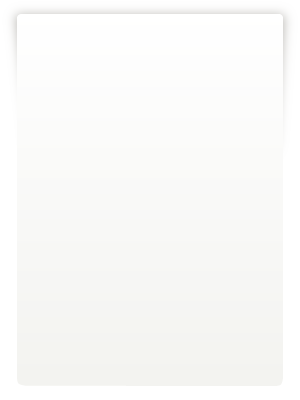
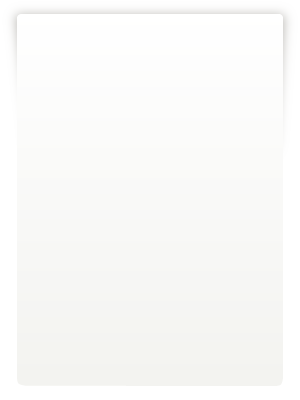
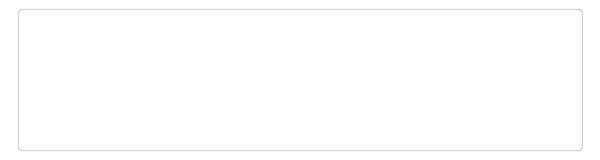
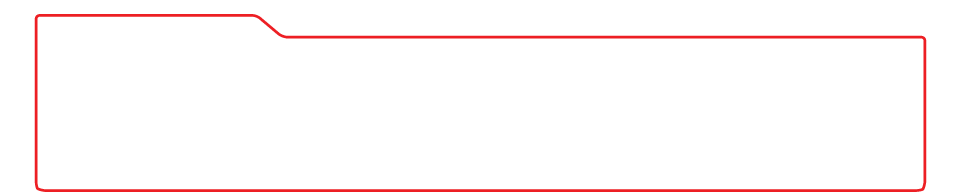
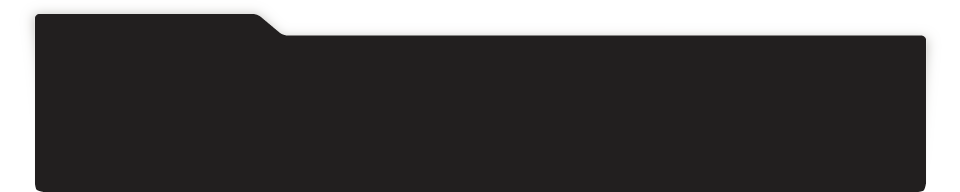
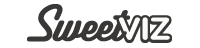
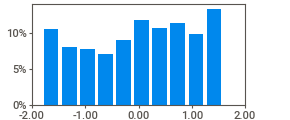
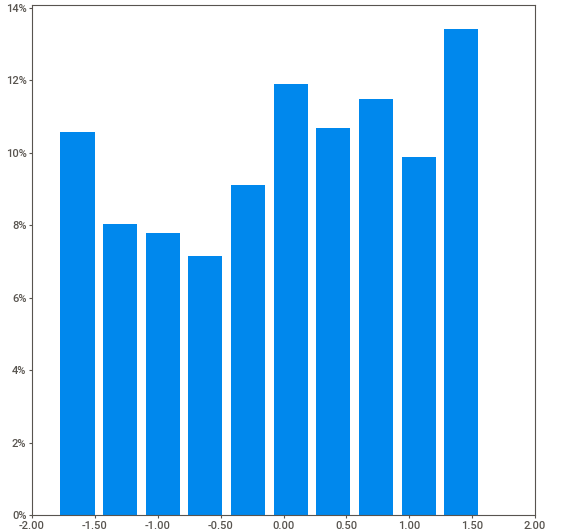
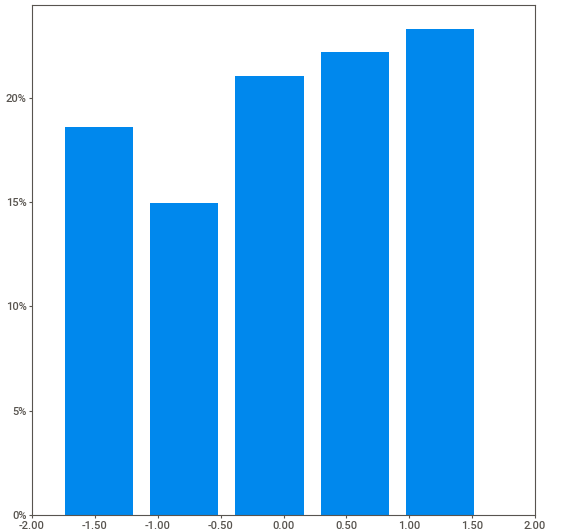
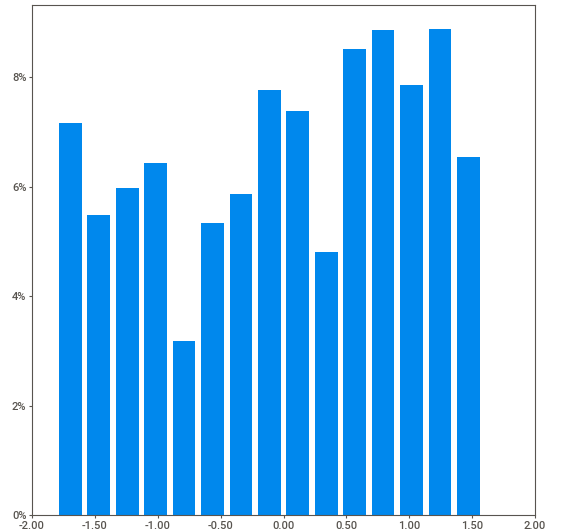
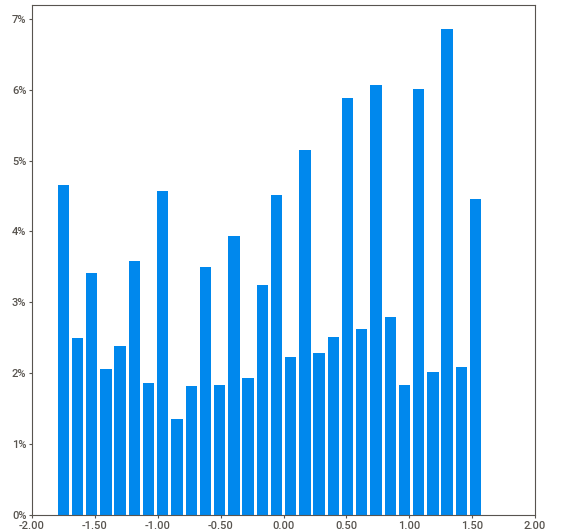
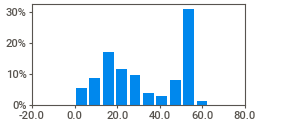
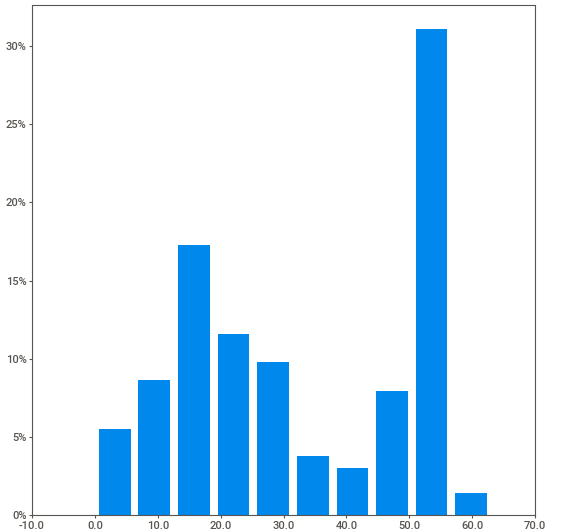
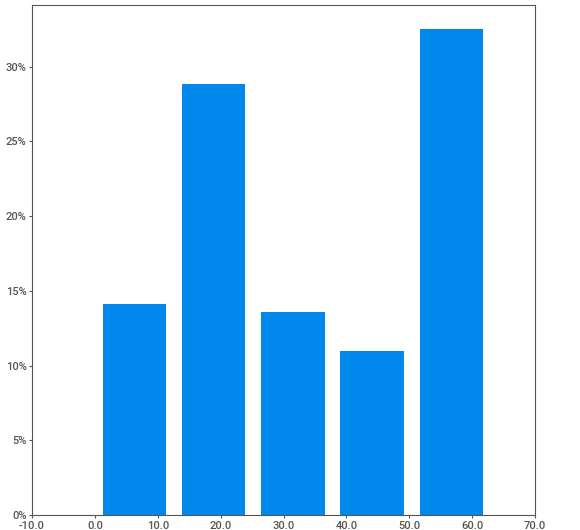
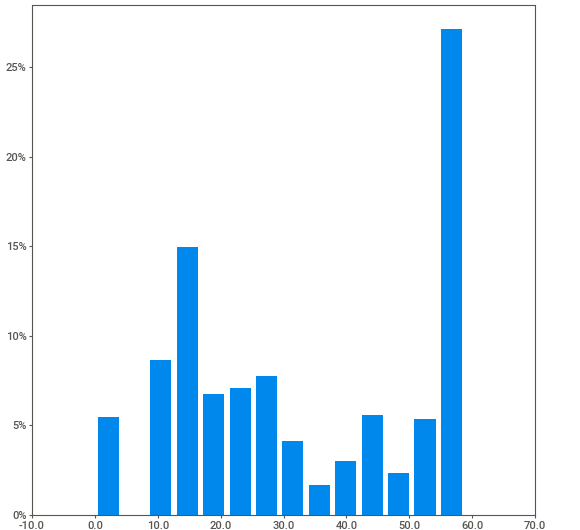
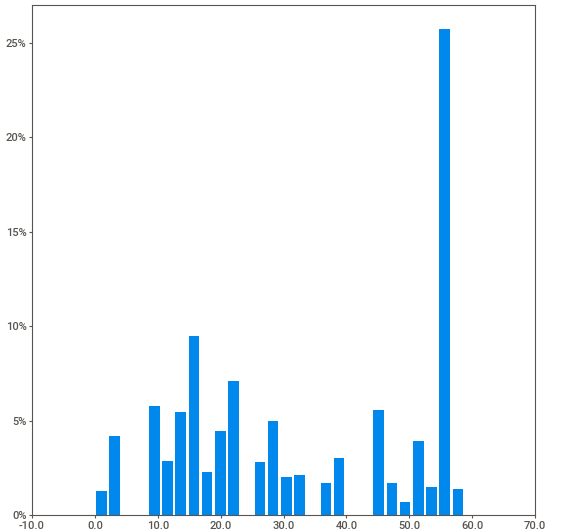
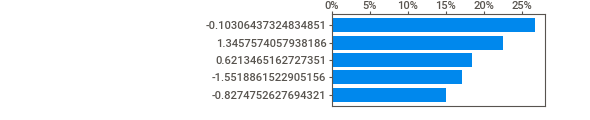
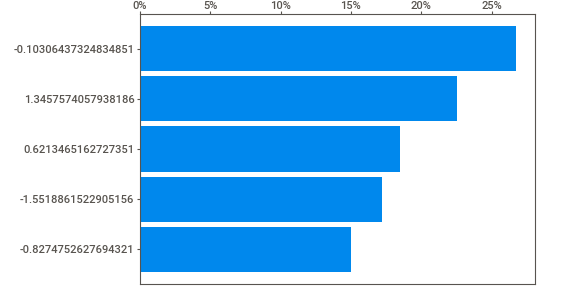
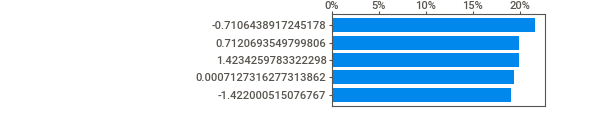
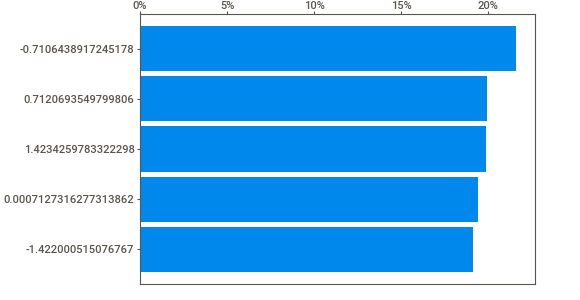
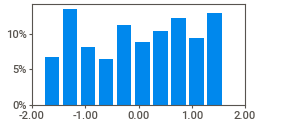
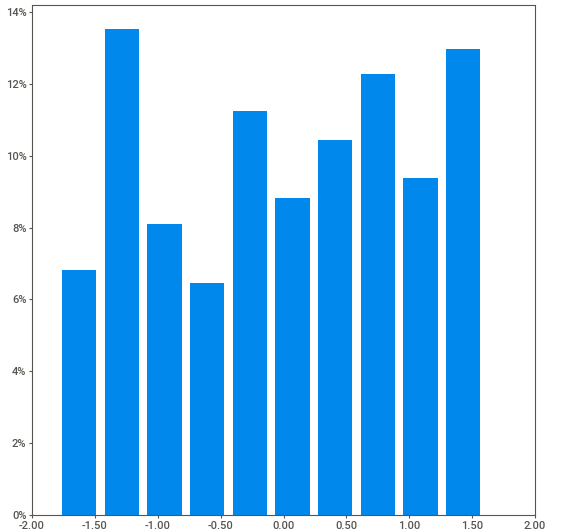
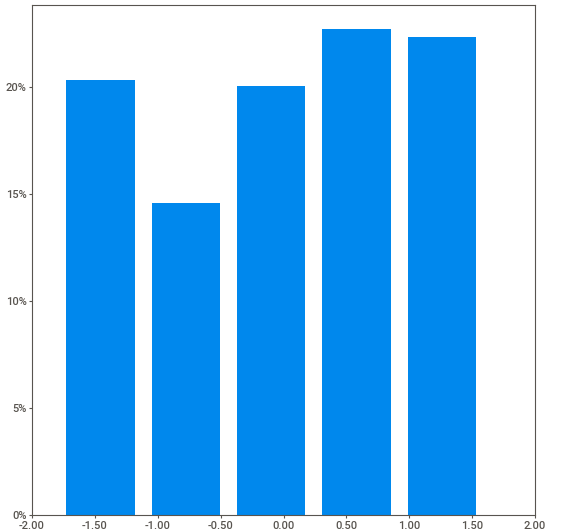
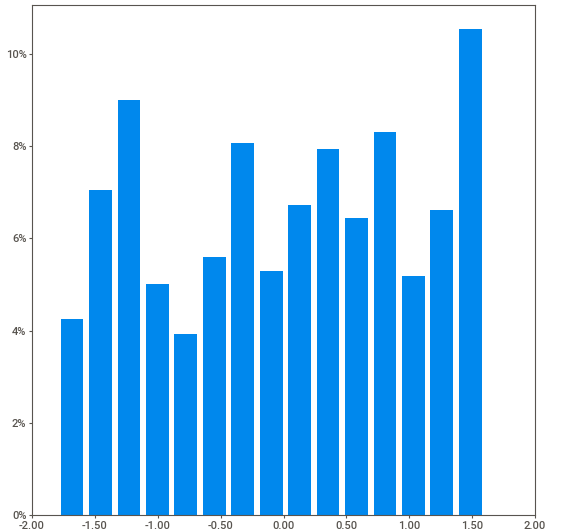
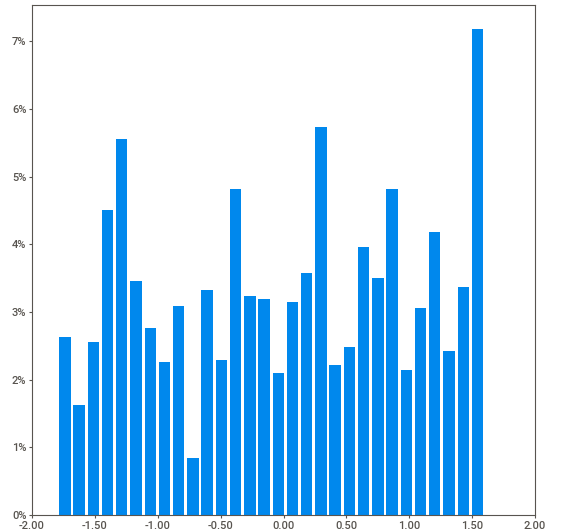
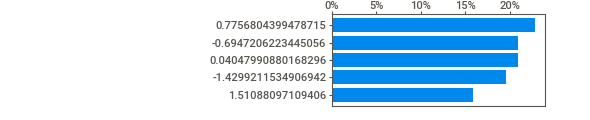
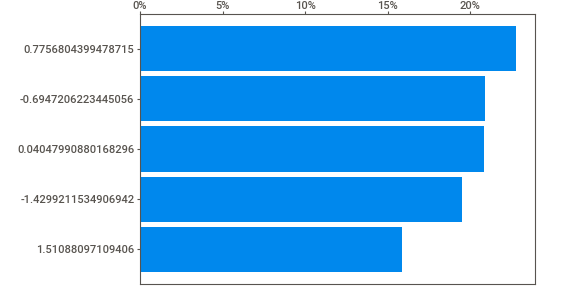
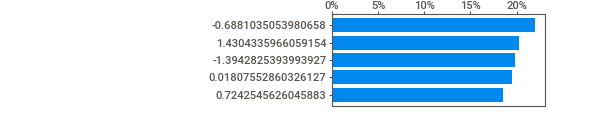
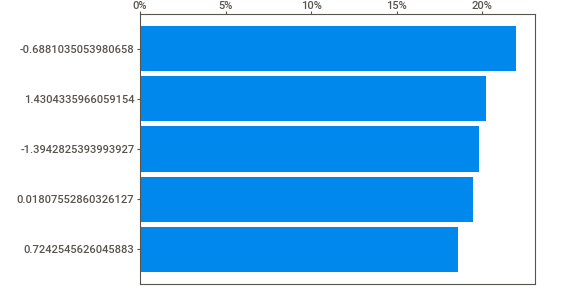
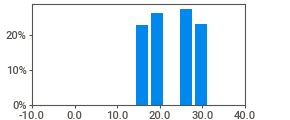
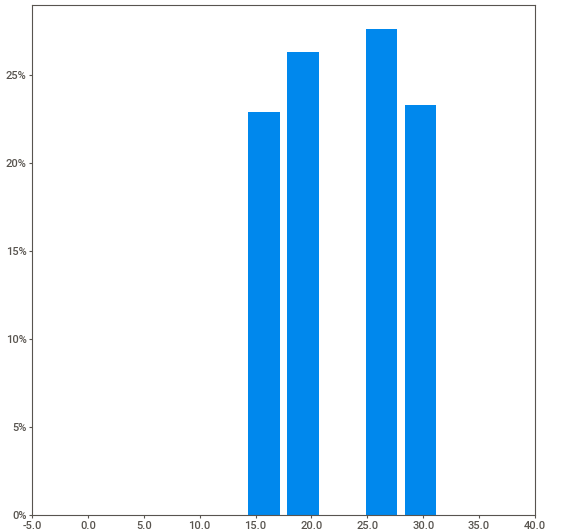
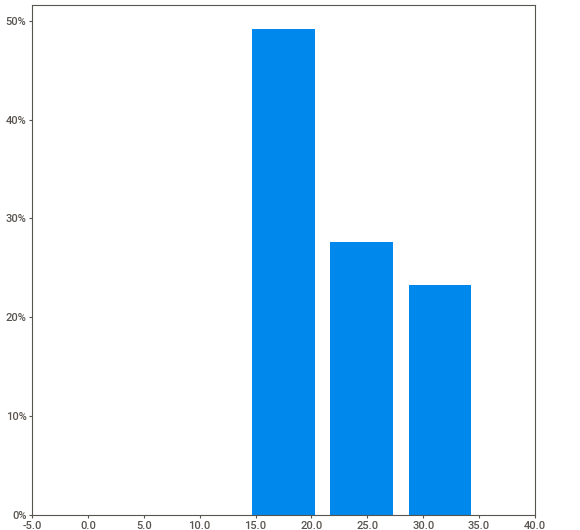
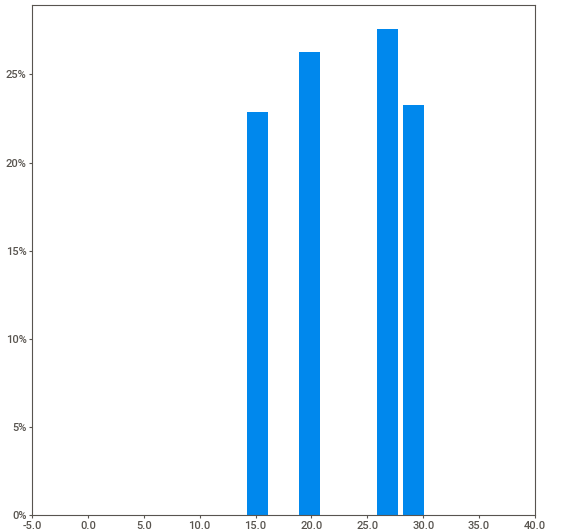
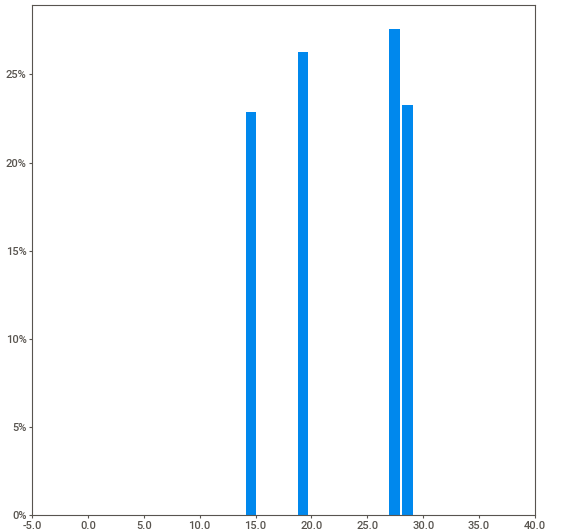
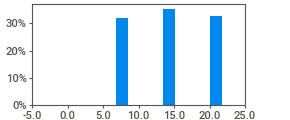
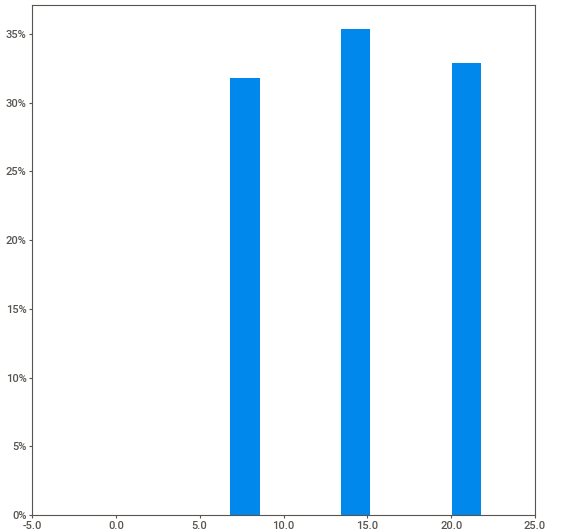
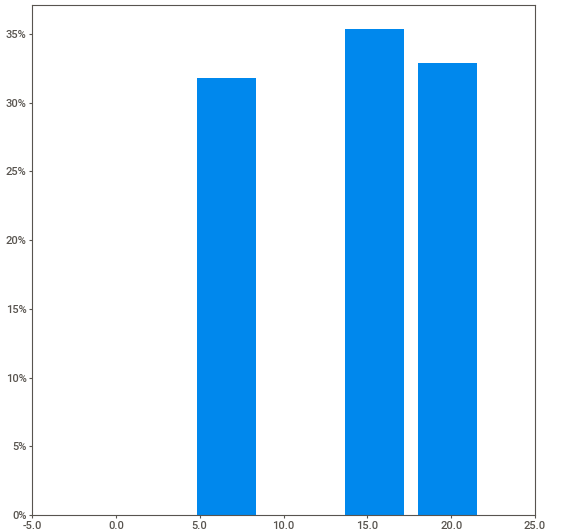
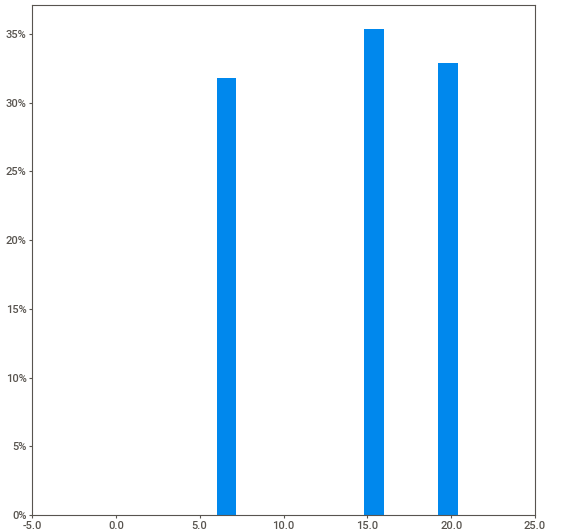
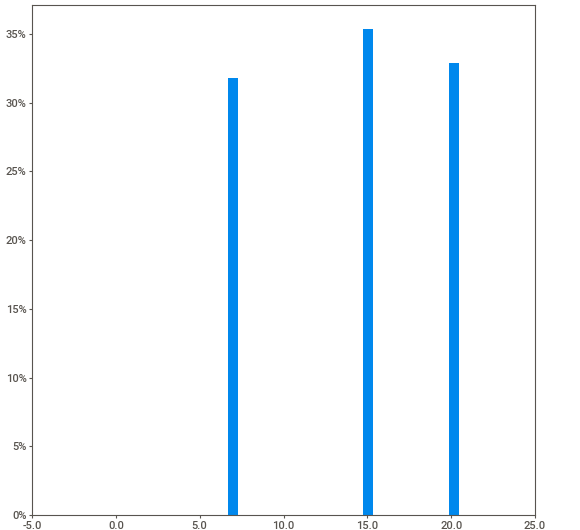
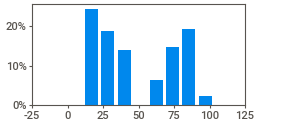
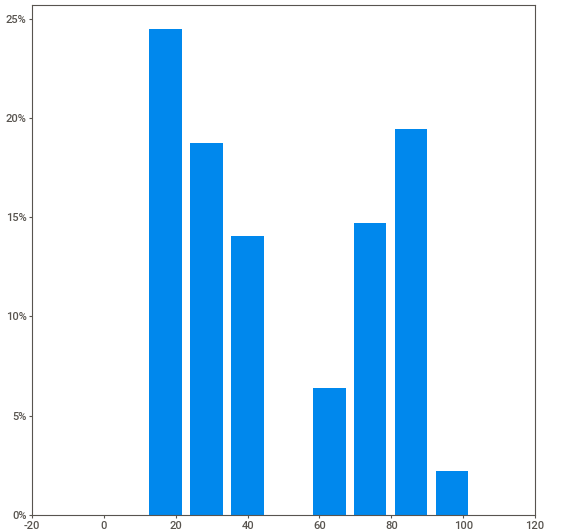
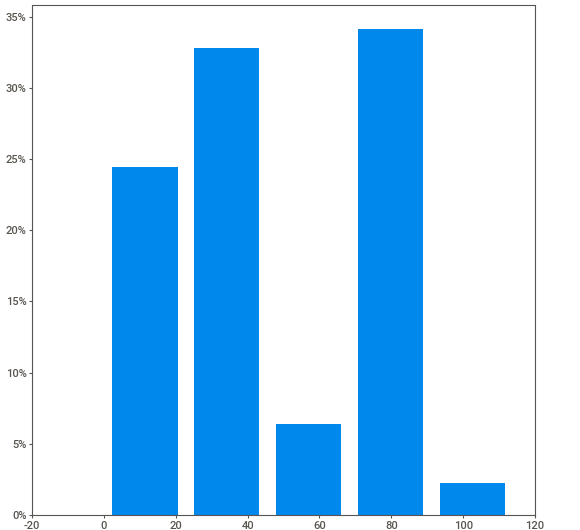
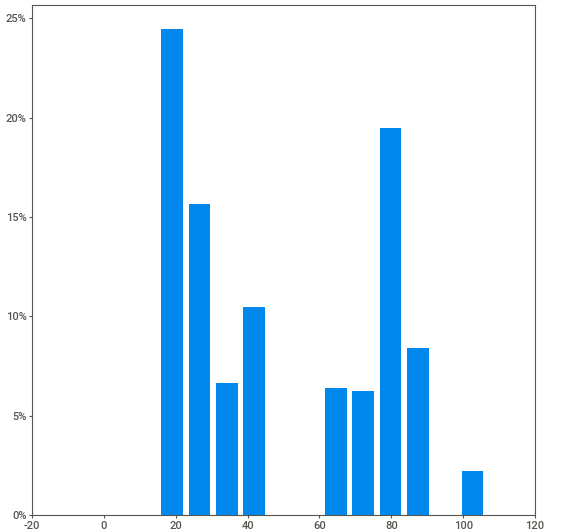
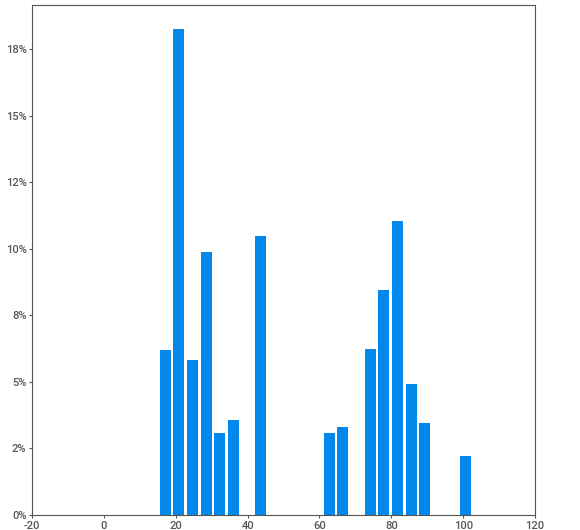
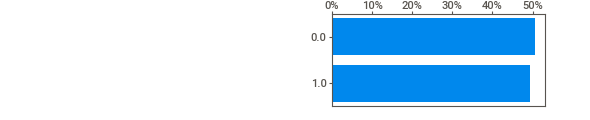
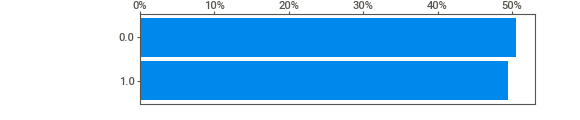
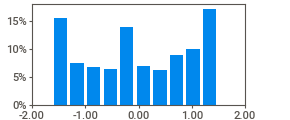
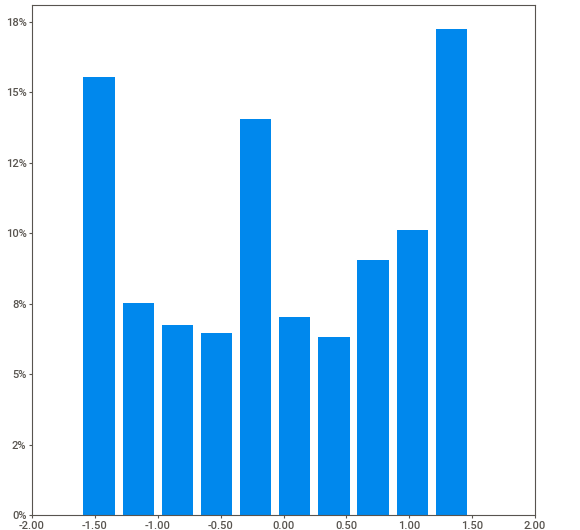
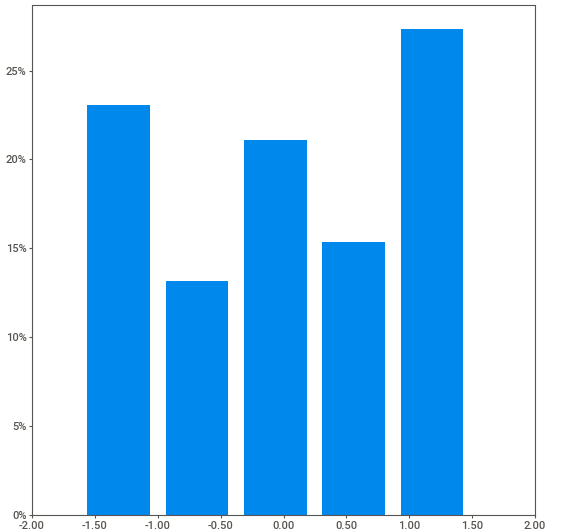
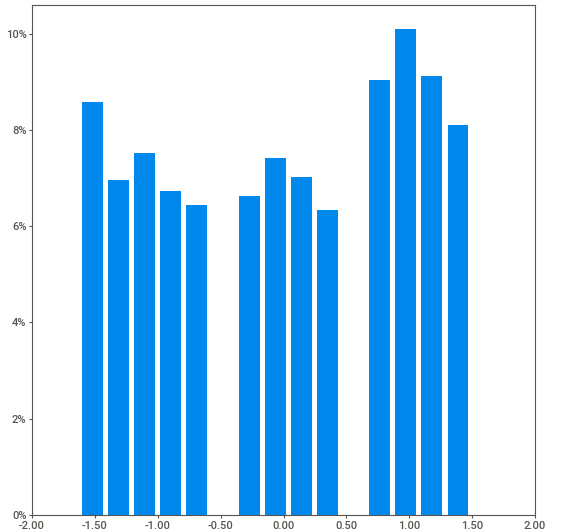
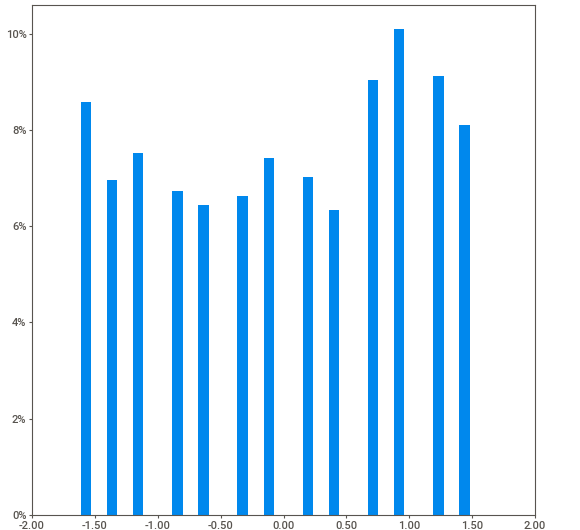
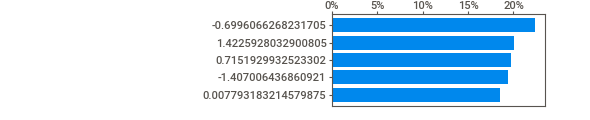
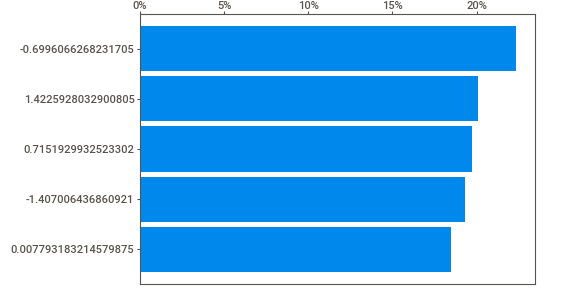
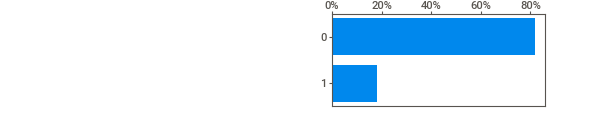
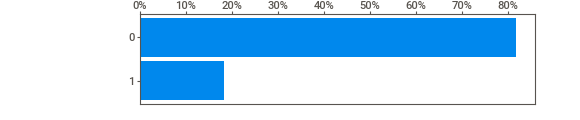
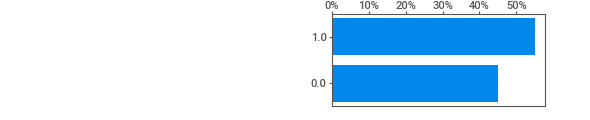
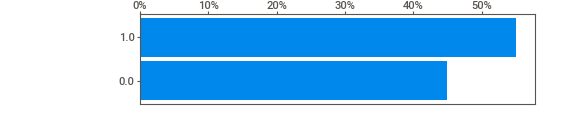
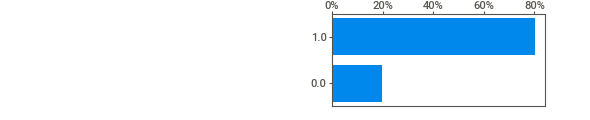
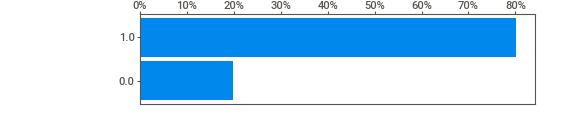
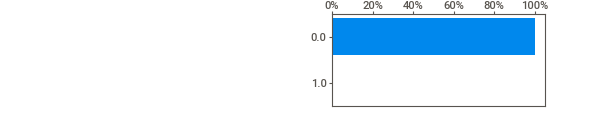
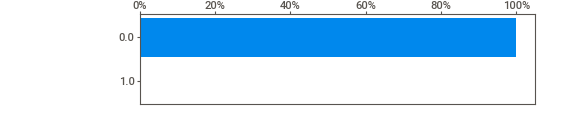
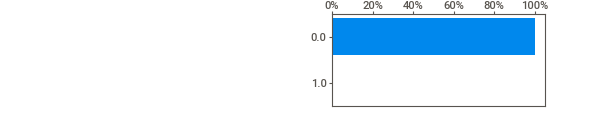
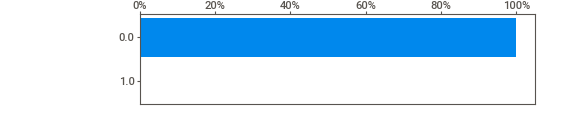
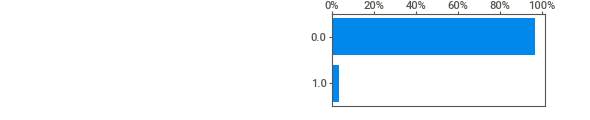
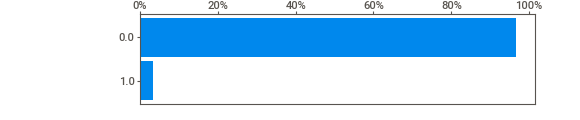
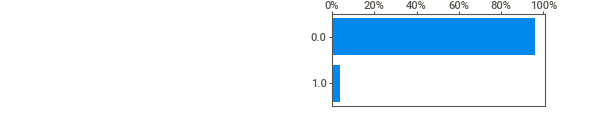
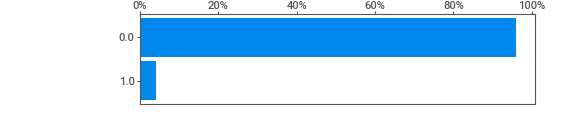
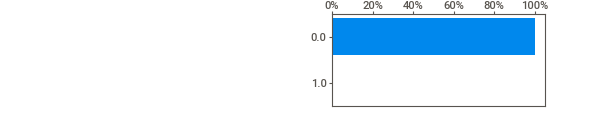
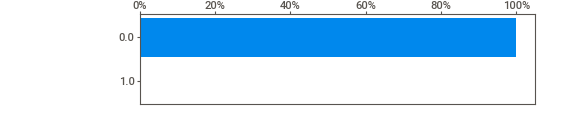
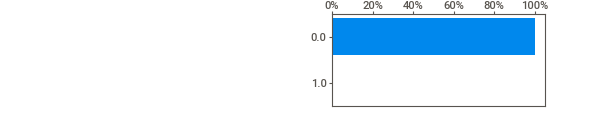
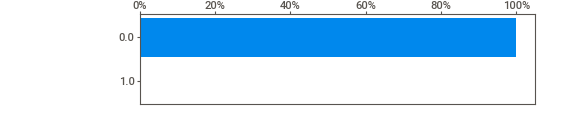
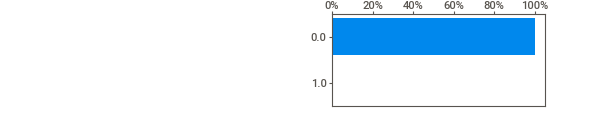
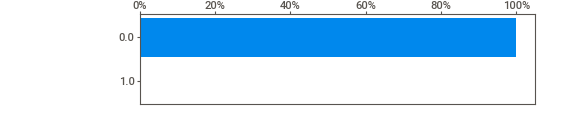
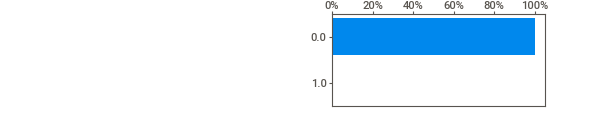
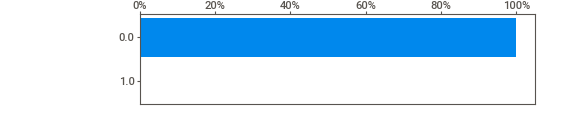
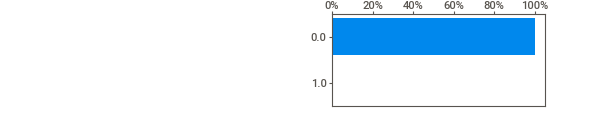
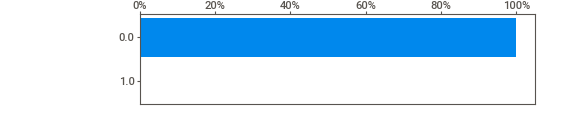
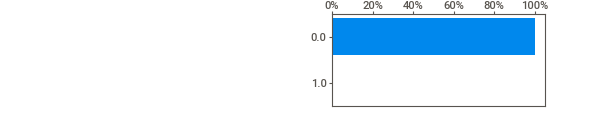
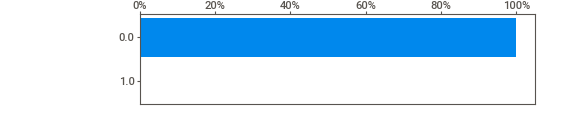
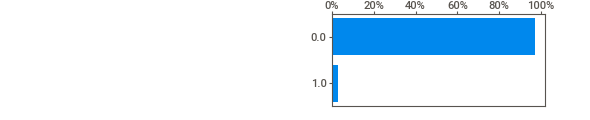
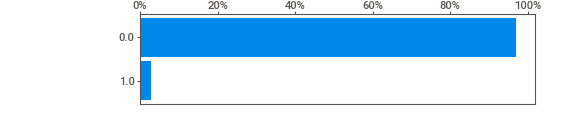
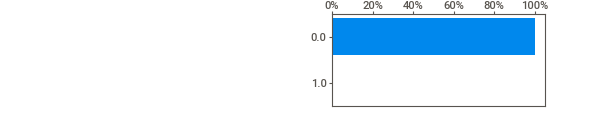
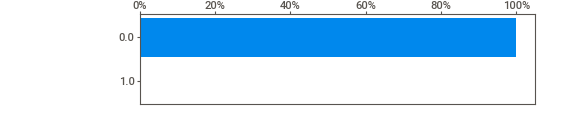
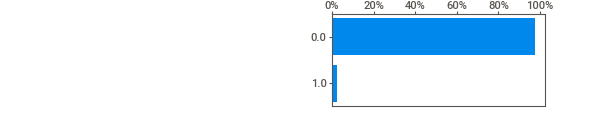
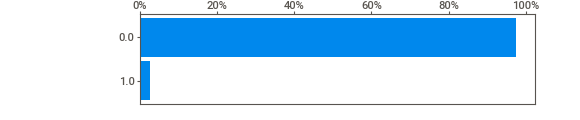
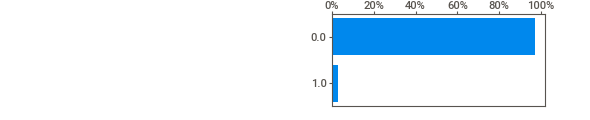
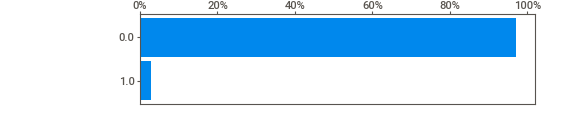
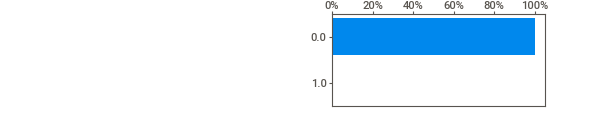
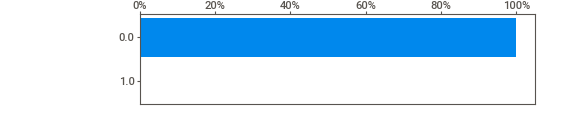
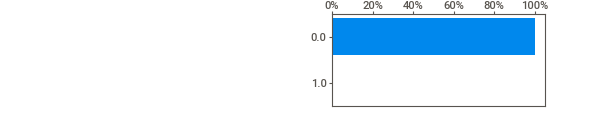
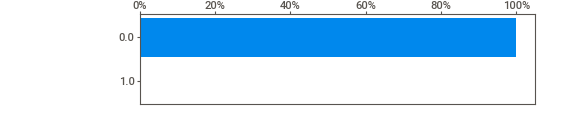
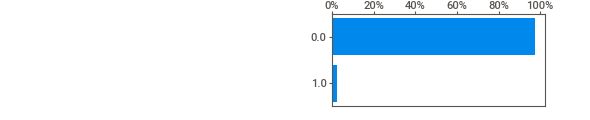
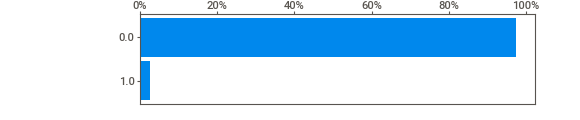
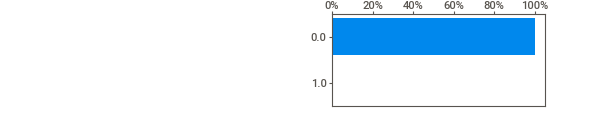
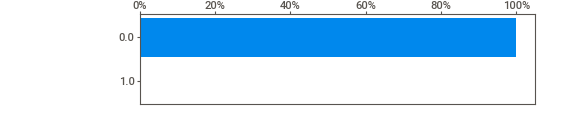
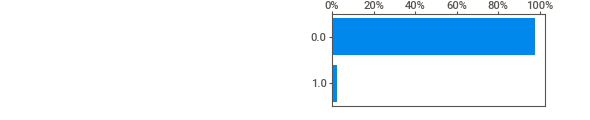
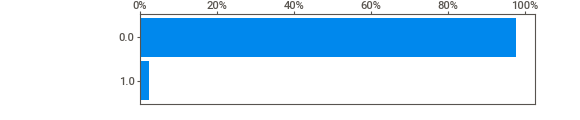
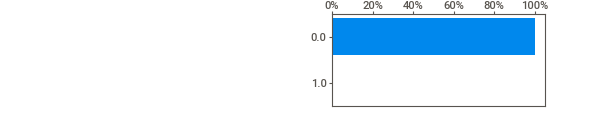
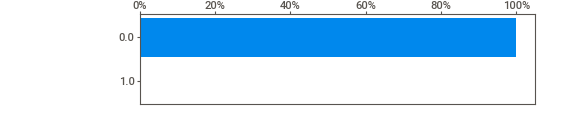
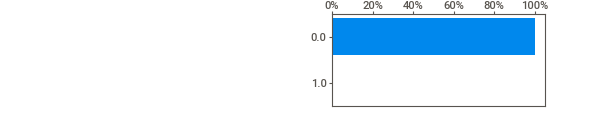
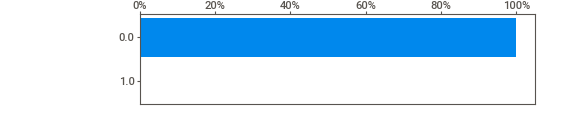
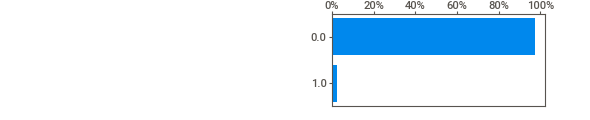
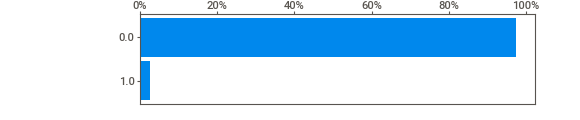
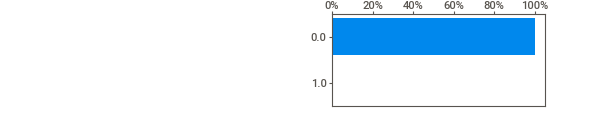
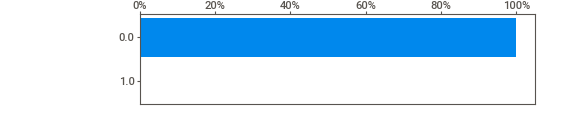
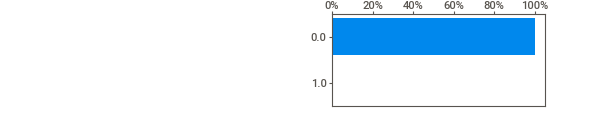
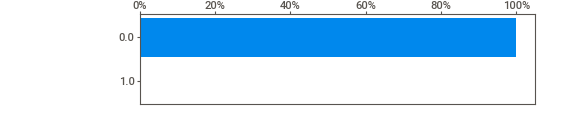
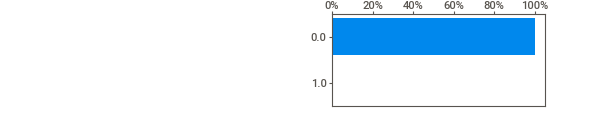
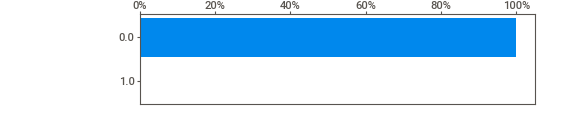
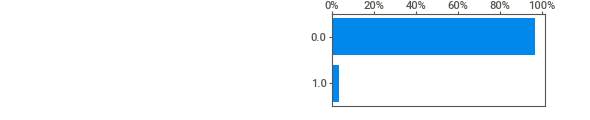
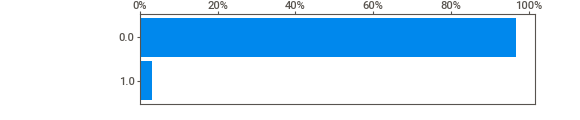
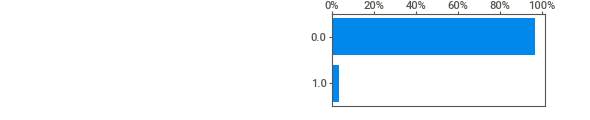
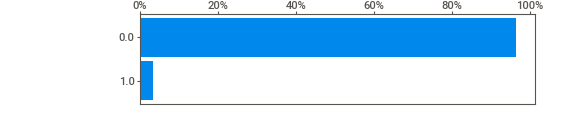
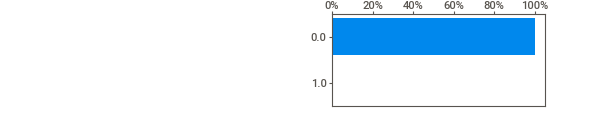
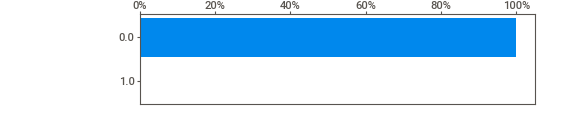
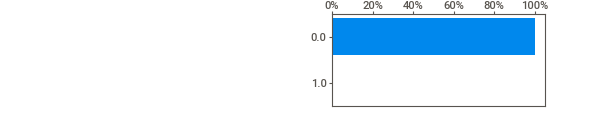
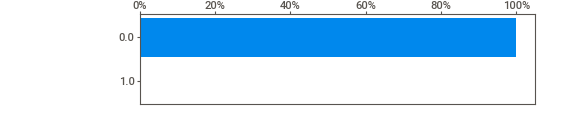
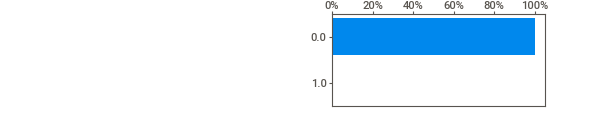
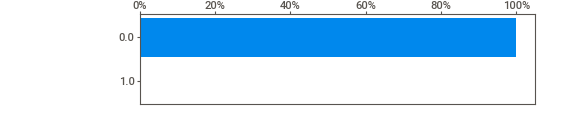
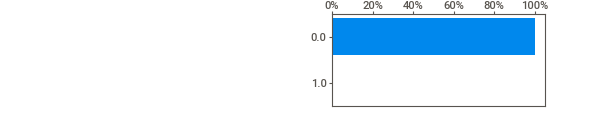
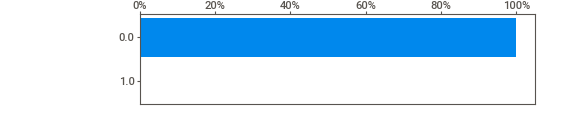
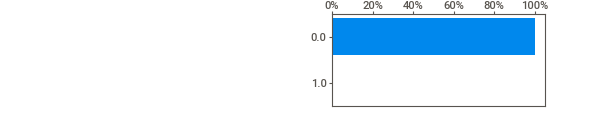
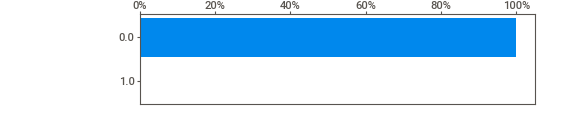
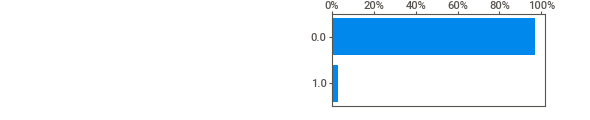
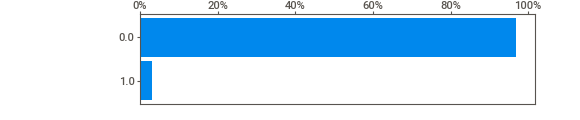
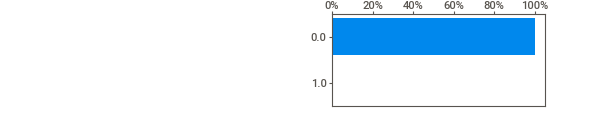
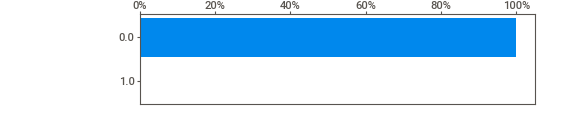
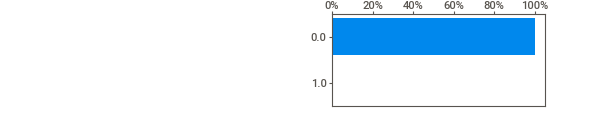
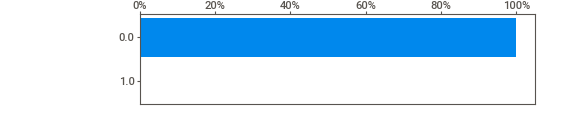
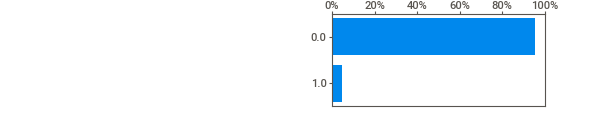
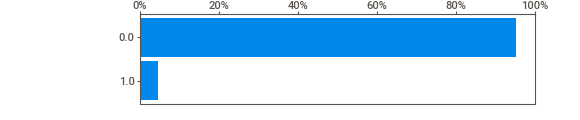
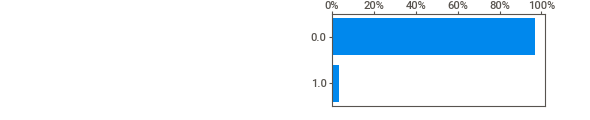
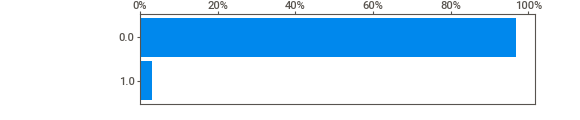
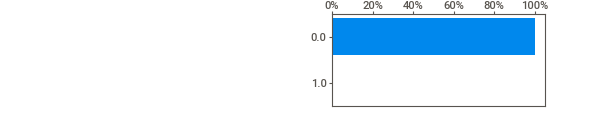
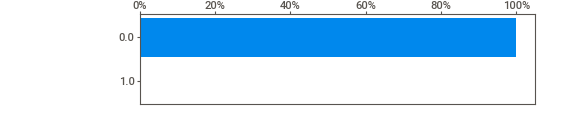
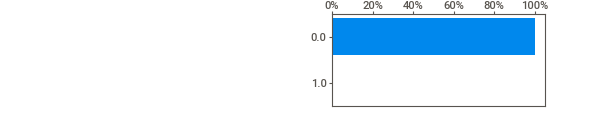
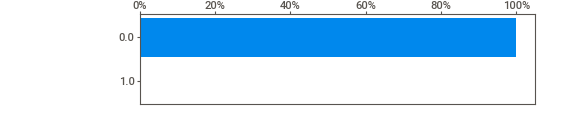
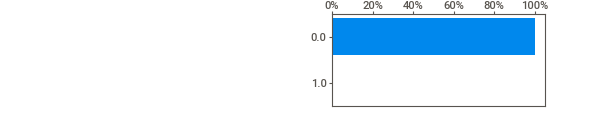
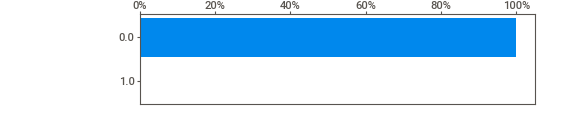
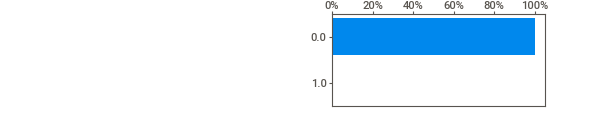
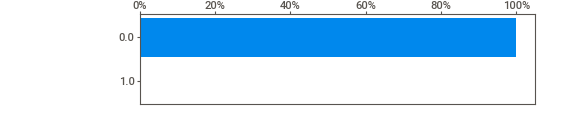
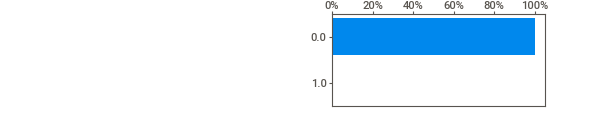
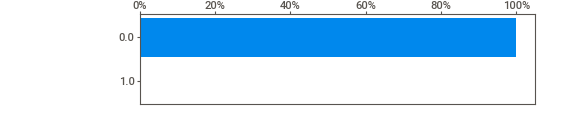
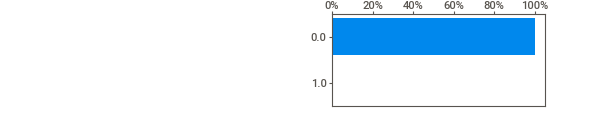
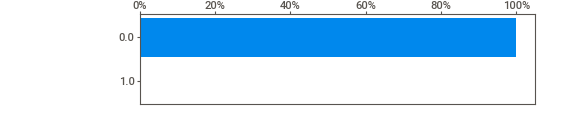
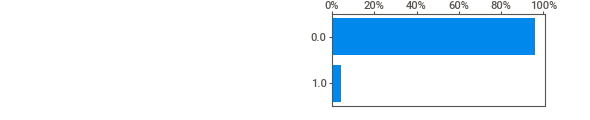
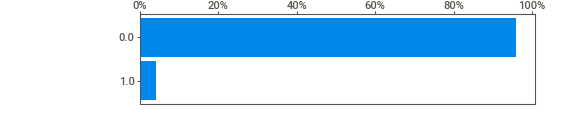
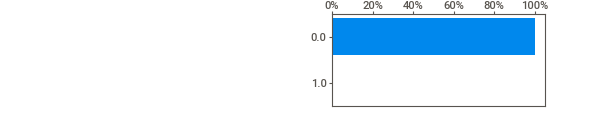
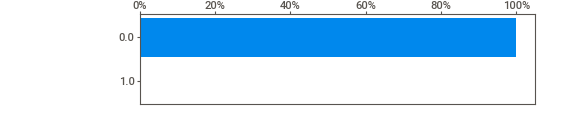
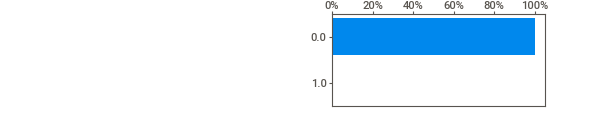
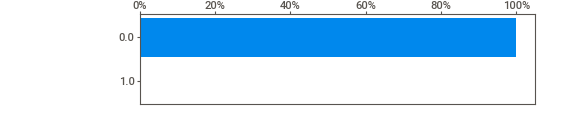
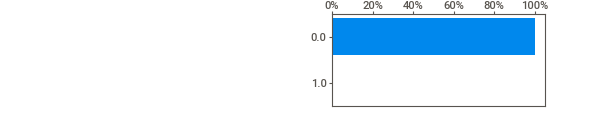
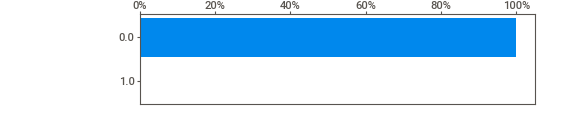
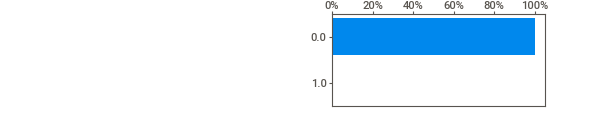
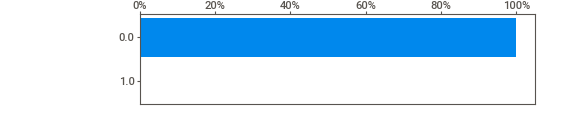
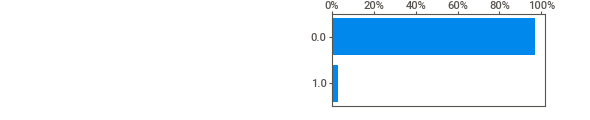
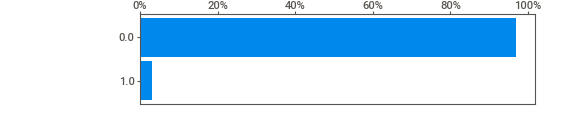
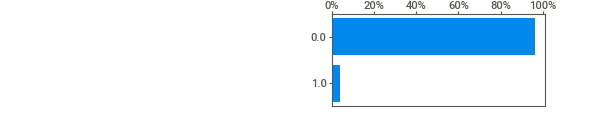
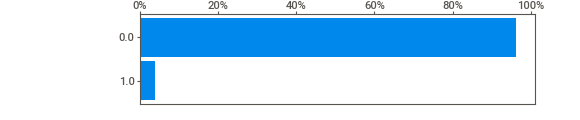
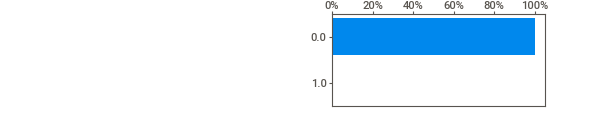
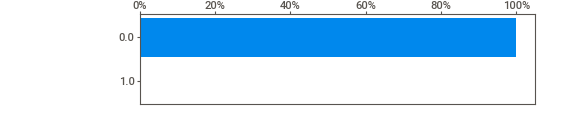
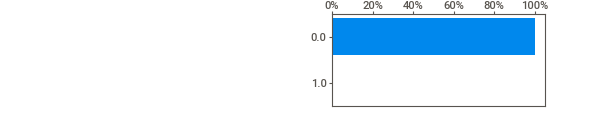
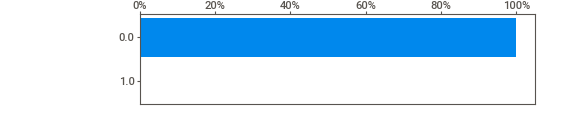
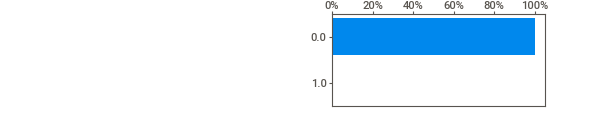
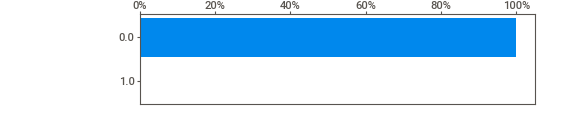
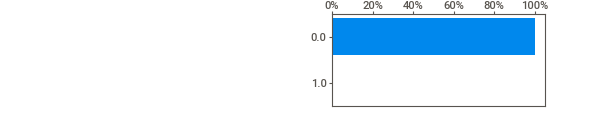
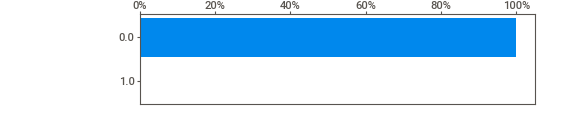
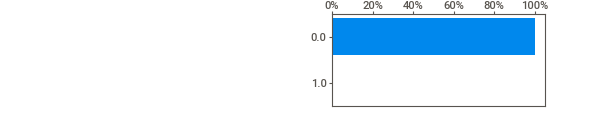
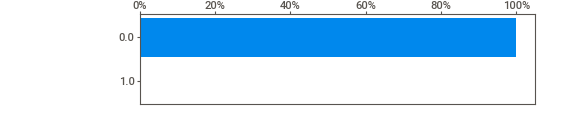
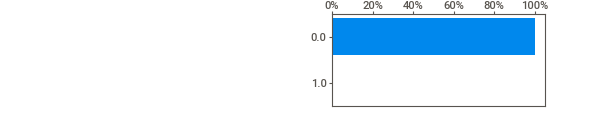
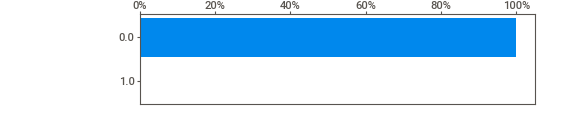
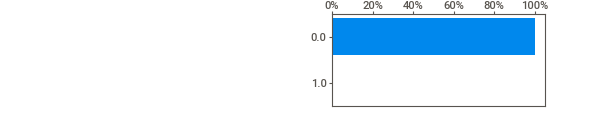
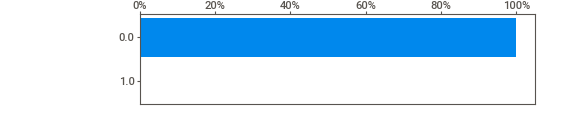
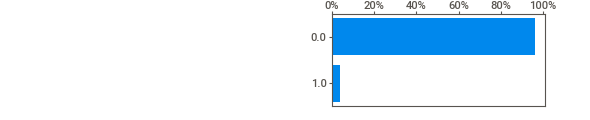
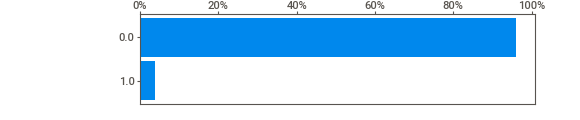
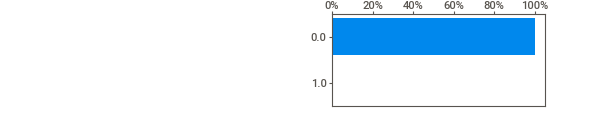
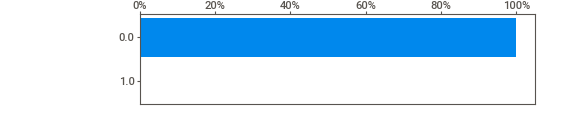
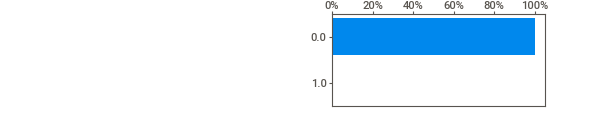
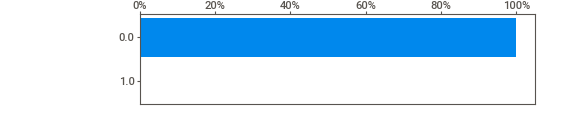
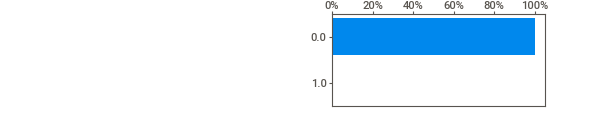
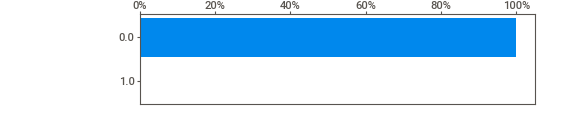
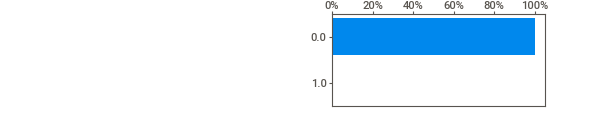
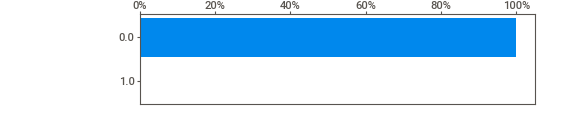
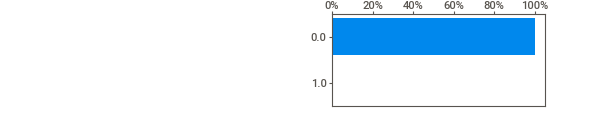
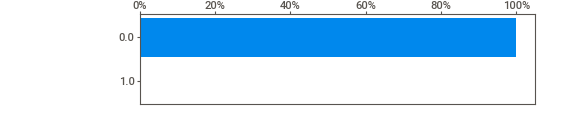
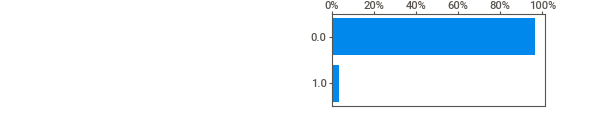
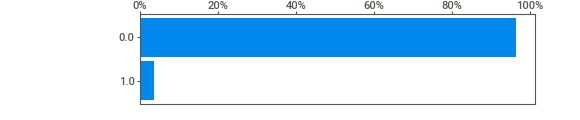
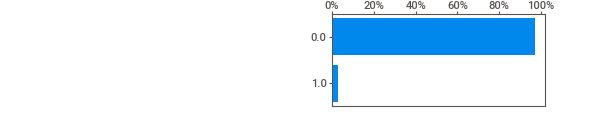
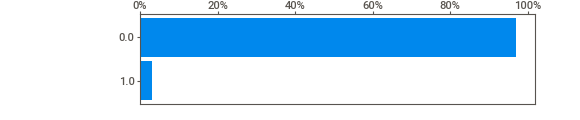
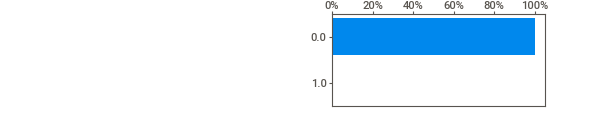
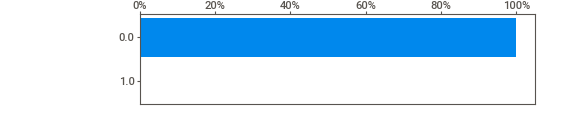
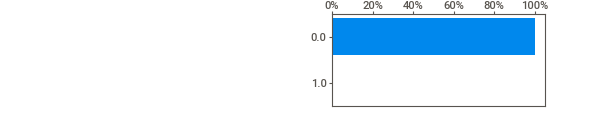
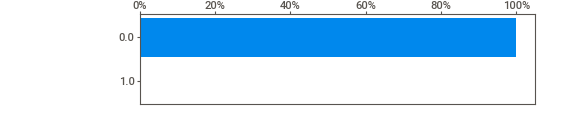
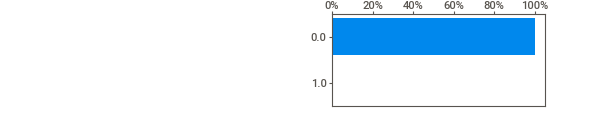
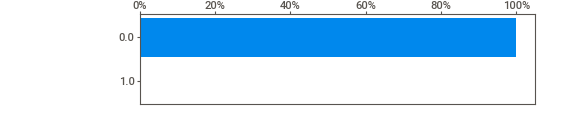
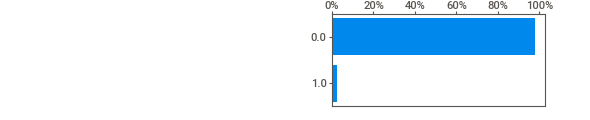
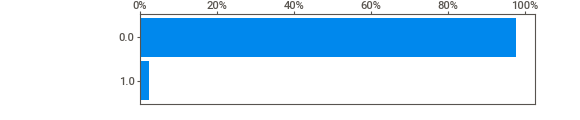
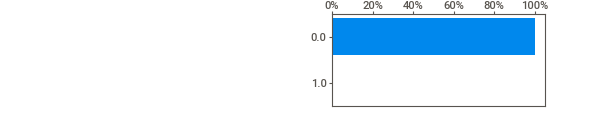
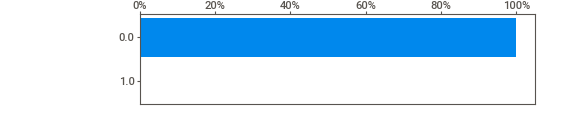
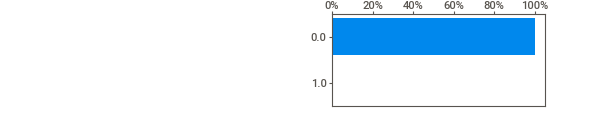
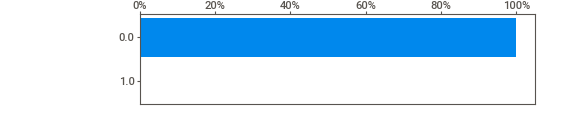
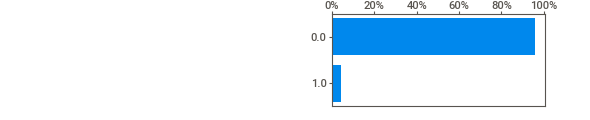
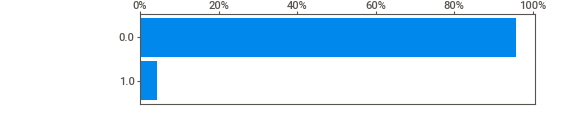
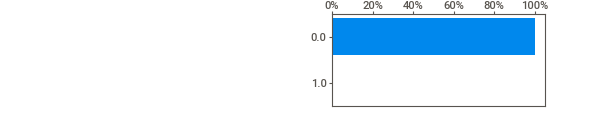
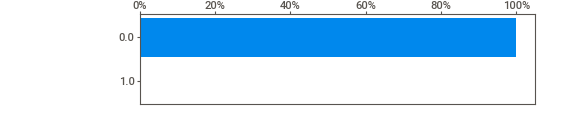
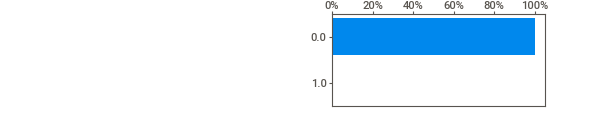
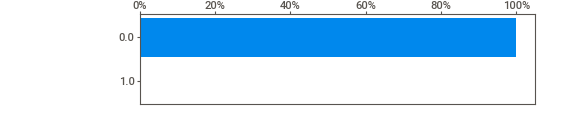
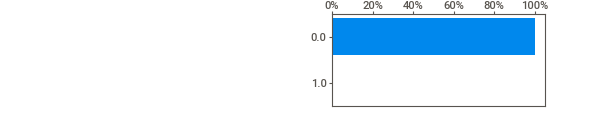
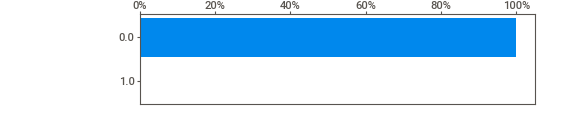
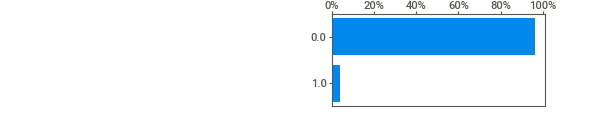
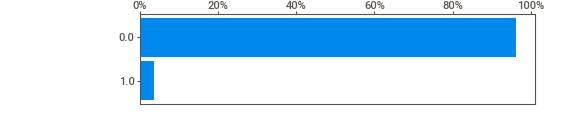
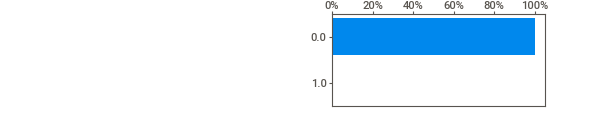
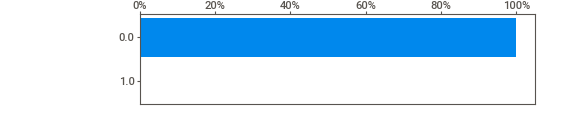
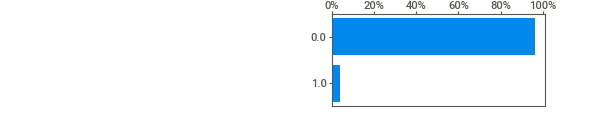
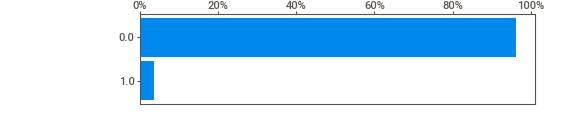
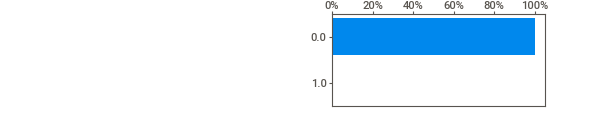
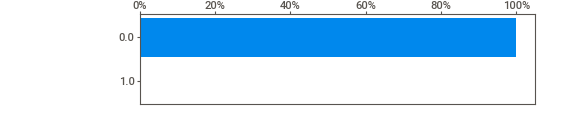
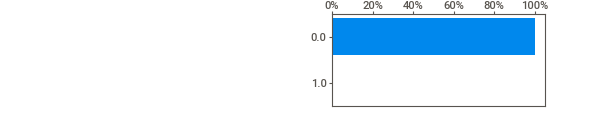
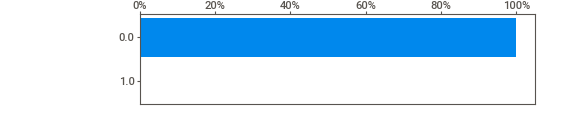
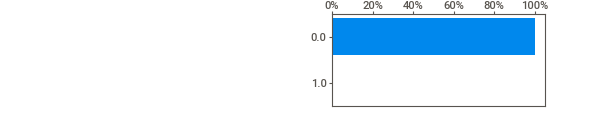
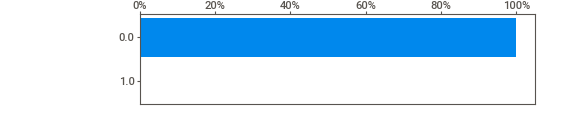
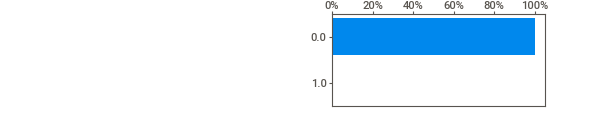
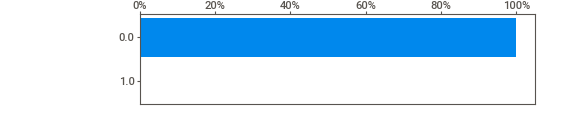
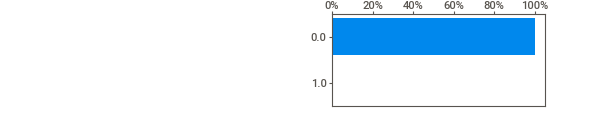
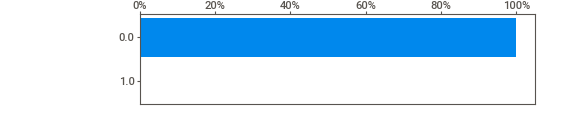
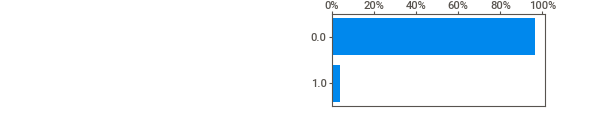
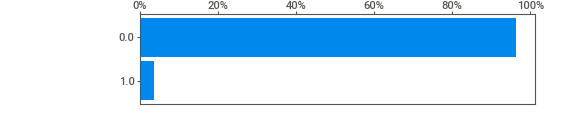
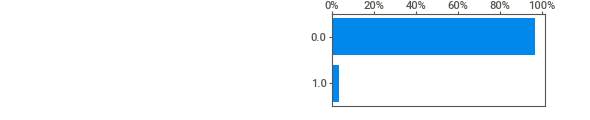
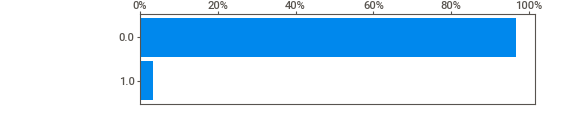
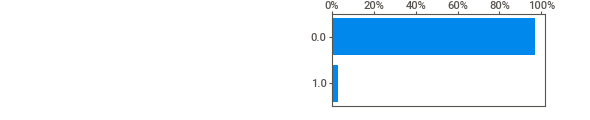
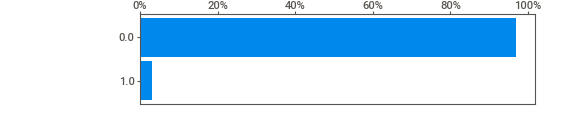
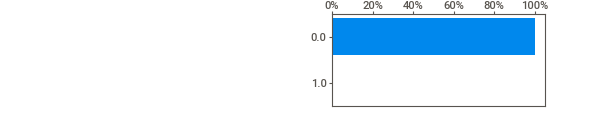
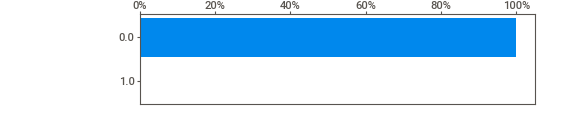
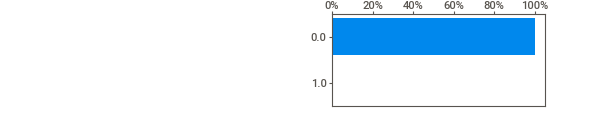
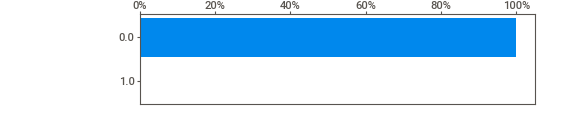
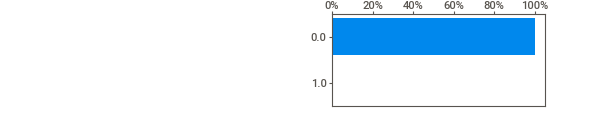
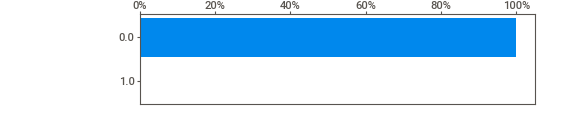
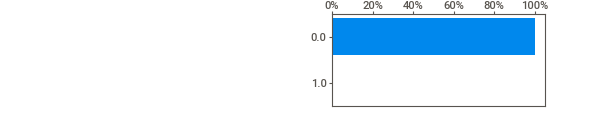
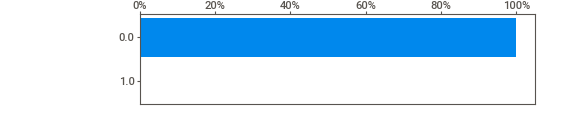
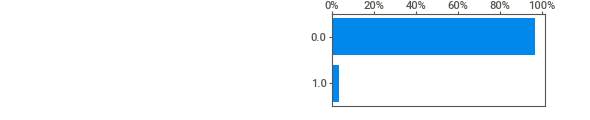
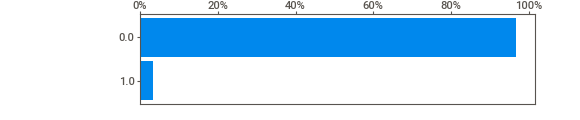
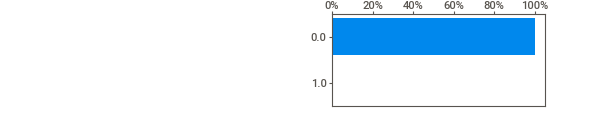
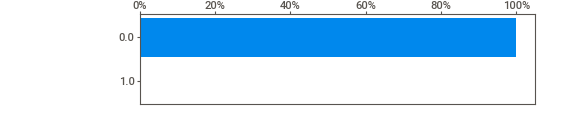
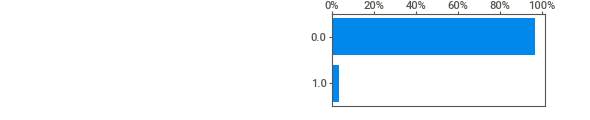
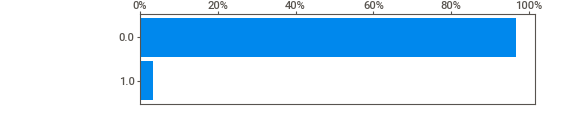
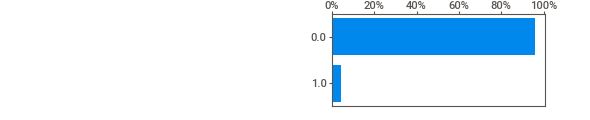
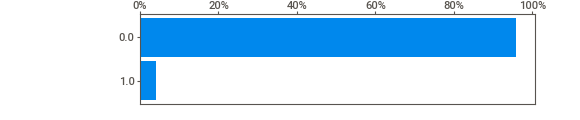
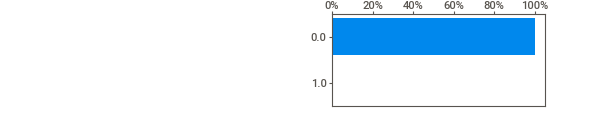
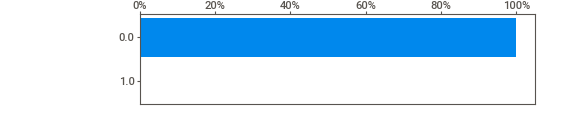
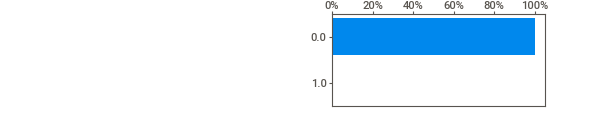
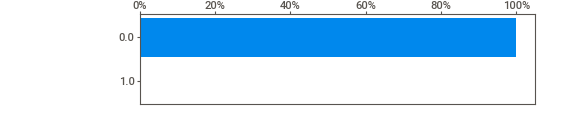
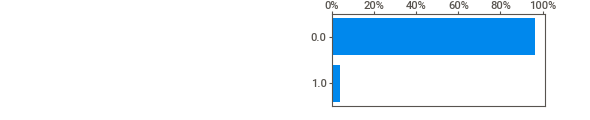
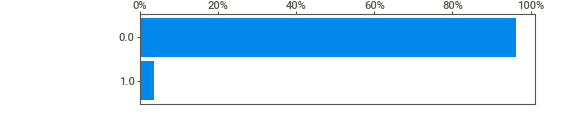
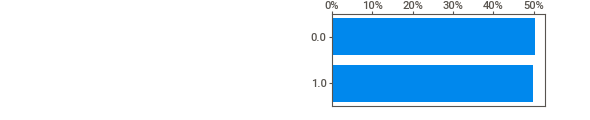
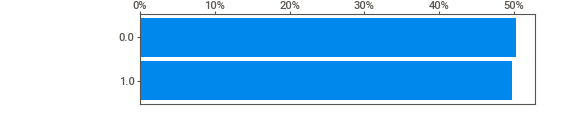
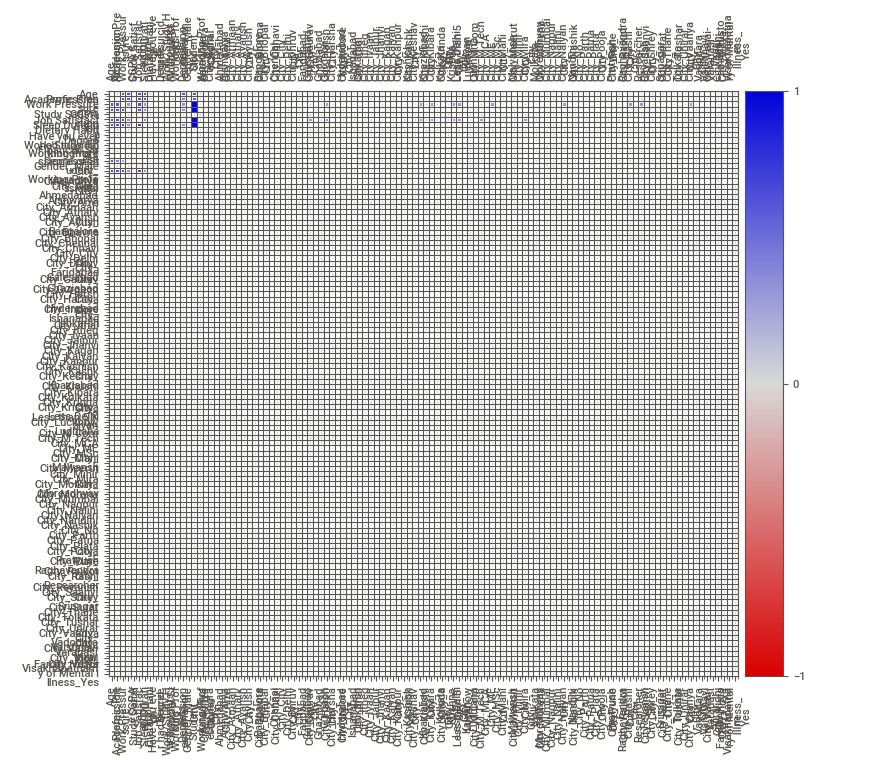
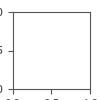

In [21]:
report = sv.analyze(train)

report.show_notebook()

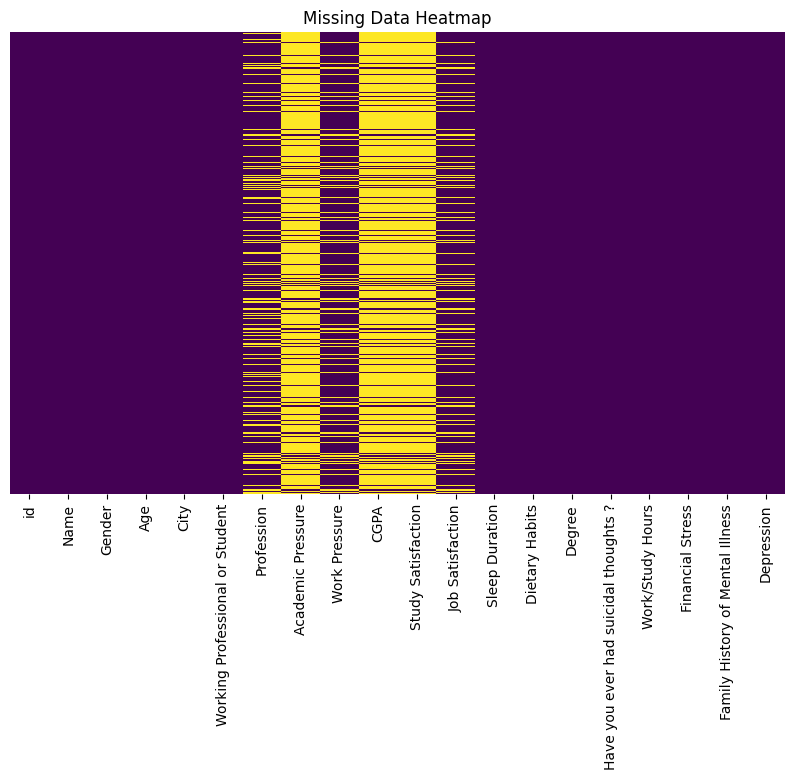

In [5]:
missing_data = train.isnull()

plt.figure(figsize=(10, 6))
sns.heatmap(missing_data, cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap')
plt.show()

<a id='c3'></a>
# <div style="text-align:center; border-radius:15px 15px; padding:15px; color:#333333; margin:0; ; padding:15px; font-size:100%; font:'Verdana'; background-color:#F5F5F5;border: 1px; overflow:hidden"><b>3. Data Analysis</b></div>


<a id='c2.1'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>1. Gender</b>

</div>

In [ ]:
pv.pie_chart('Gender')

In [ ]:
pv.histogram('Gender', hue=target)

<a id='c2.2'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>2. Age</b>

</div>

In [ ]:
pv.histogram('Age', hue=target)

<a id='c2.3'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>3. City</b>

</div>

In [ ]:
pv.histogram('City', hue=target)

<a id='c2.4'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>4. Working Professional or Student</b>

</div>

In [ ]:
pv.histogram('Working Professional or Student', hue=target)

<a id='c2.5'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>5. Profession</b>

</div>

In [ ]:
pv.histogram('Profession', hue=target)

<a id='c2.6'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>6. Academic Pressure</b>

</div>

In [ ]:
pv.histogram('Academic Pressure', hue=target)

<a id='c2.7'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>7. Work Pressure</b>

</div>

In [ ]:
pv.histogram('Work Pressure', hue=target)

<a id='c2.8'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>8. CGPA</b>

</div>

In [ ]:
pv.histogram('CGPA', hue=target)

<a id='c2.9'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>9. Study Satisfaction</b>

</div>

In [ ]:
pv.histogram('Study Satisfaction', hue=target)

<a id='c2.10'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>10. Job Satisfaction</b>

</div>

In [ ]:
pv.histogram('Study Satisfaction', hue=target)

<a id='c2.11'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>11. Sleep Duration</b>

</div>

In [ ]:
pv.histogram('Study Satisfaction', hue=target)

<a id='c2.12'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>12. Dietary Habits</b>

</div>

In [ ]:
pv.histogram('Dietary Habits', hue=target)

<a id='c2.13'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>13. Degree</b>

</div>

In [ ]:
pv.histogram('Degree', hue=target)

<a id='c2.14'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>14. Have you ever had suicidal thoughts?</b>

</div>

In [ ]:
pv.histogram('Have you ever had suicidal thoughts ?', hue=target)

<a id='c2.15'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>15. Work/Study Hours</b>

</div>

In [ ]:
pv.histogram('Work/Study Hours', hue=target)

<a id='c2.16'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>16. Financial Stress</b>

</div>

In [ ]:
pv.histogram('Financial Stress', hue=target)

<a id='c2.17'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>17. Family History of Mental Illness</b>

</div>

In [ ]:
pv.histogram('Family History of Mental Illness', hue=target)

<a id='c4'></a>
# <div style="text-align:center; border-radius:15px 15px; padding:15px; color:#333333; margin:0; ; padding:15px; font-size:100%; font:'Verdana'; background-color:#F5F5F5;border: 1px; overflow:hidden"><b>4. Model building</b>
</div>

## DataPreprocessor Class

In [6]:
class DataPreprocessor:
    """
    A class for preprocessing data with methods to fit and transform datasets.
    Allows applying the same encoders across multiple datasets.

    Params
    ----------
    numerical_columns : list of str
    one_hot_columns : list of str
    label_columns : list of str

    Attributes
    ----------
    scaler : StandardScaler
        Scaler object for numerical features.
    one_hot_encoder : OneHotEncoder
        Encoder object for one-hot encoding.
    label_encoders : dict of OrdinalEncoder
        Dictionary of OrdinalEncoders for label encoding.

    Methods
    -------
    fit(df)
        Fits the encoders on the provided DataFrame.
    transform(df)
        Transforms the DataFrame using the fitted encoders.
    fit_transform(df)
        Fits the encoders and transforms the DataFrame.
    """

    def __init__(self, numerical_columns, one_hot_columns, label_columns):
        self.numerical_columns = numerical_columns
        self.one_hot_columns = one_hot_columns
        self.label_columns = label_columns

        self.scaler = StandardScaler()
        self.one_hot_encoder = OneHotEncoder(drop='first', sparse=False, handle_unknown='ignore')
        
        self.label_encoders = {
            col: OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1) for col in self.label_columns
        }

        self.one_hot_feature_names = None

    def fit(self, df):
        self.scaler.fit(df[self.numerical_columns])

        self.one_hot_encoder.fit(df[self.one_hot_columns])
        self.one_hot_feature_names = self.one_hot_encoder.get_feature_names_out(self.one_hot_columns)

        for col in self.label_columns:
            self.label_encoders[col].fit(df[[col]])

    def transform(self, df):
        df_scaled = df.copy()

        df_scaled[self.numerical_columns] = self.scaler.transform(df[self.numerical_columns])

        encoded_columns = self.one_hot_encoder.transform(df[self.one_hot_columns])
        encoded_df = pd.DataFrame(encoded_columns, columns=self.one_hot_feature_names, index=df.index)

        for col in self.label_columns:
            df_scaled[col] = self.label_encoders[col].transform(df[[col]])

        df_final = pd.concat([df_scaled.drop(self.one_hot_columns, axis=1), encoded_df], axis=1)

        return df_final

    def fit_transform(self, df):
        self.fit(df)
        return self.transform(df)

In [7]:
import pickle

In [8]:
train = train.drop('id', axis=1)
train = train.drop('Name', axis=1)
#train[one_hot_columns + label_columns] = train[one_hot_columns + label_columns].fillna('None')
#train[numerical_columns] = train[numerical_columns].fillna(-1)

preprocessor = DataPreprocessor(numerical_columns, one_hot_columns, label_columns)

preprocessor.fit(train)

# save the preprocessor
# with open("preprocessor.pkl","wb") as f:
#     pickle.dump(preprocessor,f)

train = preprocessor.transform(train)
test = preprocessor.transform(test)

In [9]:
!pip install xgboost==1.7.6 lightgbm==4.6.0 catboost==1.2.3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 7.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 72.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 15.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.0.3
    Uninstalling xgboost-2.0.3:
      Successfully uninstalled xgboost-2.0.3
  Attempting uninstall: lightgbm
    Found existing installation: lightgbm 4.5.0
    Uninstalling lightgbm-4.5.0:
      Successfully uninstalled lightgbm-4.5.0
  Attempting uninstall: catboost
    Found existing installation: catboost 1.2.7
    Uninstalling catboost-1.2.7:
      Successfully uninstalled catboost-1.2.7


In [10]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier 

X = train.drop(target, axis=1)
y = train[target]

model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model_lgb = LGBMClassifier()
model_cat = CatBoostClassifier(verbose=0)

<a id='c5'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>Validation</b>

</div>

In [11]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

oof_preds_xgb = np.zeros(len(train))
oof_preds_lgb = np.zeros(len(train))
oof_preds_cat = np.zeros(len(train))
oof_preds_avg = np.zeros(len(train))

model_xgb.set_params(verbosity=0)
model_lgb.set_params(verbose=-1)
model_cat.set_params(verbose=False)

for train_index, valid_index in tqdm(kf.split(X), total=kf.get_n_splits(), desc="KFold Loop"):
    X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
    y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

    model_xgb.fit(X_train, y_train)
    model_lgb.fit(X_train, y_train)
    model_cat.fit(X_train, y_train)

    preds_xgb = model_xgb.predict_proba(X_valid)[:, 1]
    preds_lgb = model_lgb.predict_proba(X_valid)[:, 1]
    preds_cat = model_cat.predict_proba(X_valid)[:, 1]
    
    oof_preds_xgb[valid_index] = preds_xgb
    oof_preds_lgb[valid_index] = preds_lgb
    oof_preds_cat[valid_index] = preds_cat
    
    preds_avg = (preds_xgb + preds_lgb + preds_cat) / 3
    oof_preds_avg[valid_index] = preds_avg

score_xgb = roc_auc_score(y, oof_preds_xgb)
score_lgb = roc_auc_score(y, oof_preds_lgb)
score_cat = roc_auc_score(y, oof_preds_cat)
score_avg = roc_auc_score(y, oof_preds_avg)

KFold Loop: 100%|██████████| 10/10 [08:11<00:00, 49.17s/it]


In [12]:
print(f'OOF ROC AUC XGBoost: {score_xgb:.5f}')
print(f'OOF ROC AUC LightGBM: {score_lgb:.5f}')
print(f'OOF ROC AUC CatBoost: {score_cat:.5f}')
print(f'OOF ROC AUC Average: {score_avg:.5f}')

OOF ROC AUC XGBoost: 0.97411
OOF ROC AUC LightGBM: 0.97472
OOF ROC AUC CatBoost: 0.97511
OOF ROC AUC Average: 0.97533


In [13]:
!pwd

/kaggle/working


In [14]:
import pickle

# Save model_xgb
with open("model3_xgb.pkl", "wb") as f:
    pickle.dump(model_xgb, f)

# Save model_lgb
with open("model3_lgb.pkl", "wb") as f:
    pickle.dump(model_lgb, f)

# Save model_cat
with open("model3_cat.pkl", "wb") as f:
    pickle.dump(model_cat, f)


<a id='c6'></a>

<div style="text-align:center; border-radius:15px; padding:15px; color:#333333; margin:0; font-size:150%; font-family: 'Orbitron', sans-serif; background: #F5F5F5; background: #E8E8E8; border: 1px solid #CCCCCC; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2); overflow:hidden;">
<b>Results and submission</b>

</div>

In [ ]:
X_test = test.drop(columns=['id', 'Name'])

preds_xgb = model_xgb.predict(X_test).astype(int)
preds_lgb = model_lgb.predict(X_test).astype(int)
preds_cat = model_cat.predict(X_test).astype(int)

preds_sum = preds_xgb + preds_lgb + preds_cat
preds_hard_vote = (preds_sum >= 2).astype(int)

submit = pd.DataFrame({
    'id': test['id'],
    'prediction': preds_hard_vote.flatten()
})

submit.to_csv("../working/submission.csv", index=False)

print(submit)
print(submit['prediction'].describe())
